In [1]:
from nltk import tokenize
from operator import itemgetter
import math

In [2]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize

In [3]:
#Special module written for this class
#This provides access to data and to helper functions from previous weeks
import lucem_illud #just in case, regularly update your lucem_illud with the following code: pip install git+git://github.com/UChicago-Computational-Content-Analysis/lucem_illud.git

#All these packages need to be installed from pip
import requests #for http requests
import pandas as pd#gives us DataFrames
import matplotlib.pyplot as plt #For graphics
import wordcloud #Makes word clouds
import numpy as np #For divergences/distances
import scipy #For divergences/distances
import seaborn as sns #makes our plots look nicer
import sklearn.manifold #For a manifold plot
import json #For API responses
import urllib.parse #For joining urls

# comp-linguistics
import spacy

#Displays the graphs
import graphviz #You also need to install the command line graphviz

#These are from the standard library
import os.path
import zipfile
import subprocess
import io
import tempfile

#This 'magic' command makes the plots work better
#in the notebook, don't use it outside of a notebook
%matplotlib inline

In [3]:
data = "C:/Users/Louisa Zhao/Desktop/CORD/11/metadata.csv"

In [4]:
df = pd.read_csv(data)
df.head()

C:\Users\Louisa Zhao\AppData\Local\Programs\Python\Python39\lib\site-packages\IPython\core\interactiveshell.py:3146: DtypeWarning: Columns (1,4,5,6,13,14,15,16) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


,cord_uid,sha,source_x,title,doi,pmcid,pubmed_id,license,abstract,publish_time,authors,journal,mag_id,who_covidence_id,arxiv_id,pdf_json_files,pmc_json_files,url,s2_id
0,ug7v899j,d1aafb70c066a2068b02786f8929fd9c900897fb,PMC,Clinical features of culture-proven Mycoplasma...,10.1186/1471-2334-1-6,PMC35282,11472636,no-cc,OBJECTIVE: This retrospective chart review des...,2001-07-04,"Madani, Tariq A; Al-Ghamdi, Aisha A",BMC Infect Dis,NaN,NaN,NaN,document_parses/pdf_json/d1aafb70c066a2068b027...,document_parses/pmc_json/PMC35282.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3...,NaN
1,02tnwd4m,6b0567729c2143a66d737eb0a2f63f2dce2e5a7d,PMC,Nitric oxide: a pro-inflammatory mediator in l...,10.1186/rr14,PMC59543,11667967,no-cc,Inflammatory diseases of the respiratory tract...,2000-08-15,"Vliet, Albert van der; Eiserich, Jason P; Cros...",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/6b0567729c2143a66d737...,document_parses/pmc_json/PMC59543.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN
2,ejv2xln0,06ced00a5fc04215949aa72528f2eeaae1d58927,PMC,Surfactant protein-D and pulmonary host defense,10.1186/rr19,PMC59549,11667972,no-cc,Surfactant protein-D (SP-D) participates in th...,2000-08-25,"Crouch, Erika C",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/06ced00a5fc04215949aa...,document_parses/pmc_json/PMC59549.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN
3,2b73a28n,348055649b6b8cf2b9a376498df9bf41f7123605,PMC,Role of endothelin-1 in lung disease,10.1186/rr44,PMC59574,11686871,no-cc,Endothelin-1 (ET-1) is a 21 amino acid peptide...,2001-02-22,"Fagan, Karen A; McMurtry, Ivan F; Rodman, David M",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/348055649b6b8cf2b9a37...,document_parses/pmc_json/PMC59574.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN
4,9785vg6d,5f48792a5fa08bed9f56016f4981ae2ca6031b32,PMC,Gene expression in epithelial cells in respons...,10.1186/rr61,PMC59580,11686888,no-cc,Respiratory syncytial virus (RSV) and pneumoni...,2001-05-11,"Domachowske, Joseph B; Bonville, Cynthia A; Ro...",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/5f48792a5fa08bed9f560...,document_parses/pmc_json/PMC59580.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN


In [5]:
clean_df = df[['cord_uid','title','abstract']]

In [6]:
clean_df['text'] = clean_df['abstract'] + clean_df['title']

<ipython-input-6-2edea10e0571>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df['text'] = clean_df['abstract'] + clean_df['title']


In [7]:
clean_df.head()

,cord_uid,title,abstract,text
0,ug7v899j,Clinical features of culture-proven Mycoplasma...,OBJECTIVE: This retrospective chart review des...,OBJECTIVE: This retrospective chart review des...
1,02tnwd4m,Nitric oxide: a pro-inflammatory mediator in l...,Inflammatory diseases of the respiratory tract...,Inflammatory diseases of the respiratory tract...
2,ejv2xln0,Surfactant protein-D and pulmonary host defense,Surfactant protein-D (SP-D) participates in th...,Surfactant protein-D (SP-D) participates in th...
3,2b73a28n,Role of endothelin-1 in lung disease,Endothelin-1 (ET-1) is a 21 amino acid peptide...,Endothelin-1 (ET-1) is a 21 amino acid peptide...
4,9785vg6d,Gene expression in epithelial cells in respons...,Respiratory syncytial virus (RSV) and pneumoni...,Respiratory syncytial virus (RSV) and pneumoni...


In [22]:
def get_data(data):
    df = pd.read_csv(data)
    clean_df = df[['cord_uid','title','abstract']]
    clean_df['txt'] = clean_df['abstract'] + clean_df['title']

# Normalize the text data

In [54]:
def clean_raw_text(raw_texts):
    clean_texts = []
    for text in raw_texts:
        try:
            text = text.decode("utf-8")
            clean_text = text.replace(" \'m", "'m").replace(" \'ll", "'ll").replace(" \'re", "'re").replace(" \'s", "'s").replace(" \'re", "'re").replace(" n\'t", "n't").replace(" \'ve", "'ve").replace(" /'d", "'d")
            clean_texts.append(clean_text)
            print(clean_text)
        except AttributeError:
            # print("ERROR CLEANING")
            # print(text)
            continue
        except UnicodeDecodeError:
            # print("Unicode Error, Skip")
            continue
    return clean_texts

In [9]:
t = clean_df['text']

In [10]:
lst_text = [i for i in t]
print(lst_text[2])

Surfactant protein-D (SP-D) participates in the innate response to inhaled microorganisms and organic antigens, and contributes to immune and inflammatory regulation within the lung. SP-D is synthesized and secreted by alveolar and bronchiolar epithelial cells, but is also expressed by epithelial cells lining various exocrine ducts and the mucosa of the gastrointestinal and genitourinary tracts. SP-D, a collagenous calcium-dependent lectin (or collectin), binds to surface glycoconjugates expressed by a wide variety of microorganisms, and to oligosaccharides associated with the surface of various complex organic antigens. SP-D also specifically interacts with glycoconjugates and other molecules expressed on the surface of macrophages, neutrophils, and lymphocytes. In addition, SP-D binds to specific surfactant-associated lipids and can influence the organization of lipid mixtures containing phosphatidylinositol in vitro. Consistent with these diverse in vitro activities is the observati

In [28]:
import sys
sys.path.append(r'C:\Users\Louisa Zhao\anaconda3\Lib\site-packages')
sys.path.append(r'C:\Users\Louisa Zhao\anaconda3\Lib\site-packages\en_core_sci_md')

nlp = spacy.load(r'C:\Users\Louisa Zhao\anaconda3\Lib\site-packages\en_core_sci_md-0.4.0\en_core_sci_md\en_core_sci_md-0.4.0')

C:\Users\Louisa Zhao\AppData\Local\Programs\Python\Python39\lib\site-packages\spacy\util.py:275: UserWarning: [W031] Model 'en_core_sci_md' (0.4.0) requires spaCy v3.0 and is incompatible with the current spaCy version (2.3.5). This may lead to unexpected results or runtime errors. To resolve this, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)


In [39]:
def word_tokenize(word_list):
    tokenized = []
    # pass word list through language model.
    doc = nlp(word_list)
    for token in doc:
        if not token.is_punct and len(token.text.strip()) > 0:
            tokenized.append(token.text)
    return tokenized

In [114]:
txt = word_tokenize(lst_text[2])
normalizeTokens(txt)

' surfactant protein d sp d participate innate response inhale microorganism organic antigen contribute immune inflammatory regulation lung sp d synthesize secrete alveolar bronchiolar epithelial cell express epithelial cell line exocrine duct mucosa gastrointestinal genitourinary tract sp d collagenous calcium dependent lectin collectin bind surface glycoconjugate express wide variety microorganism oligosaccharide associate surface complex organic antigen sp d specifically interact glycoconjugate molecule express surface macrophage neutrophil lymphocyte addition sp d bind specific surfactant associate lipid influence organization lipid mixture contain phosphatidylinositol vitro consistent diverse vitro activity observation sp d deficient transgenic mouse abnormal accumulation surfactant lipid respond abnormally challenge respiratory virus bacterial lipopolysaccharide phenotype macrophage isolate lung sp d deficient mouse alter circumstantial evidence abnormal oxidant metabolism and/or

In [40]:
def normalizeTokens(word_list, extra_stop=[]):
    #We can use a generator here as we just need to iterate over it
    normalized = []
    text = " "
    if type(word_list) == list and len(word_list) == 1:
        word_list = word_list[0]

    if type(word_list) == list:
        word_list = ' '.join([str(elem) for elem in word_list]) 

    doc = nlp(word_list.lower())
    
    # add the property of stop word to words considered as stop words
    if len(extra_stop) > 0:
        for stopword in extra_stop:
            lexeme = nlp.vocab[stopword]
            lexeme.is_stop = True

    for w in doc:
        # if it's not a stop word or punctuation mark, add it to our article
        if w.text != '\n' and not w.is_stop and not w.is_punct and not w.like_num and len(w.text.strip()) > 0:
            # we add the lematized version of the word
            normalized.append(str(w.lemma_))
            
    for n in normalized:
        text = text + n + " "

    return text

In [14]:
def normalizeList(norm_list):
    clean_norm_lst = []
    for text in norm_list:
        lst = normalizeTokens(text, extra_stop=[])
        clean_norm_lst.append(lst)
    return clean_norm_lst

In [15]:
t = normalizeTokens(lst_text[2])
t

' surfactant protein-d sp-d participates innate response inhaled microorganisms organic antigens contributes immune inflammatory regulation lung sp-d synthesized secreted alveolar bronchiolar epithelial cells expressed epithelial cells lining exocrine ducts mucosa gastrointestinal genitourinary tracts sp-d collagenous calcium-dependent lectin collectin binds surface glycoconjugates expressed wide variety microorganisms oligosaccharides associated surface complex organic antigens sp-d specifically interacts glycoconjugates molecules expressed surface macrophages neutrophils lymphocytes addition sp-d binds specific surfactant-associated lipids influence organization lipid mixtures containing phosphatidylinositol vitro consistent diverse vitro activities observation sp-d-deficient transgenic mice abnormal accumulations surfactant lipids respond abnormally challenge respiratory viruses bacterial lipopolysaccharides phenotype macrophages isolated lungs sp-d-deficient mice altered circumstan

In [124]:
from random import sample
sample_lst = sample(lst_text,int(len(lst_text)*0.01))

In [125]:
len(sample_lst)

4001

In [126]:
final_clean_lst = []

for text in sample_lst:
    try:
        token = word_tokenize(text)
        final_clean_lst.append(normalizeTokens(token))
    except Exception:
        pass

In [127]:
final_clean_lst[:10]

[' background point care bedside lung ultrasound diagnostic adjunct management respiratory disease describe clinical progress lung ultrasound finding singaporean covid-19 intensive care unit patient diagnose covid-19 infection method clinical course covid-19 patient manage intensive care unit trace patient diagnose covid-19 virus infection intubate develop respiratory failure serial point care bedside lung ultrasound perform manage intensivist daily correlate clinical progress chest x ray imaging patient result patient exhibit lung ultrasound finding consistent describe viral pneumonia include numerous b line subpleural consolidation disrupt pleural line distribute symmetrically predominantly bilateral upper blue point low blue point bilaterally coalesce b line lead development bilateral white lung associate worsen acute respiratory distress syndrome increase density reduction b line associate clinical improvement deterioration respectively conclusion train clinicians familiar point ca

In [128]:
print("total num of valid abstract is:",len(final_clean_lst))

total num of valid abstract is: 2901


sample data:

In [42]:
from random import sample

sample_lst = sample(final_clean_lst,int(287728*0.1))

In [43]:
len(sample_lst)

28772

# POS Tagging

In [129]:
from textblob import TextBlob
blob = TextBlob(final_clean_lst[0])
print(blob.noun_phrases)

['background point care bedside lung ultrasound diagnostic adjunct management respiratory disease describe clinical progress lung ultrasound', 'singaporean covid-19 intensive care unit patient diagnose covid-19 infection method clinical course covid-19 patient manage intensive care unit trace patient diagnose covid-19 virus infection intubate', 'respiratory failure serial point care bedside lung ultrasound', 'manage intensivist', 'correlate clinical progress chest x ray', 'patient result patient exhibit lung ultrasound', 'consistent describe viral pneumonia', 'numerous b line subpleural consolidation disrupt pleural line', 'bilateral upper blue point', 'low blue point', 'coalesce b line lead development', 'bilateral white lung', 'associate worsen', 'acute respiratory distress syndrome increase density reduction b line', 'associate clinical improvement deterioration', 'conclusion train clinicians', 'familiar point care lung ultrasonography', 'point care bedside ultrasound', 'important a

In [130]:
from spacy.lang.en import English
p = English(parser=True, tagger=True, entity=True)

In [88]:
from spacy import displacy
nlp = spacy.load('en_core_web_sm')
doc = nlp("Autonomous cars shift insurance liability toward manufacturers")
displacy.render(doc, style='dep')
for chunk in doc.noun_chunks:
    print(chunk.text, chunk.root.text, chunk.root.dep_, chunk.root.head.text)

Autonomous cars cars nsubj shift
insurance liability liability dobj shift
manufacturers manufacturers pobj toward


# Extract Phrase

In [131]:
from gensim.summarization import keywords
print(keywords(final_clean_lst[4]))

grpr
tumor
tumors
targeting
receptor agonist
amba target
base antagonist
bombesin
release
tomography
emission
value
imaging
vivo
assay
evaluate effect
immunofluorescence


In [98]:
a = keywords(final_clean_lst[0])

'patients\npneumonia\npneumoniae infections\ninfection\ncommon infants\ncomorbidities\nculture\nchildren\ncultures respiratory\nidentified\ncharts\ncrepitations\nchart review\ndied\nreviewed results\nimmunocompromised\nclinical'

In [102]:
print(type(a.split('\n')))

<class 'list'>


In [207]:
final_clean_lst[0]

' background point care bedside lung ultrasound diagnostic adjunct management respiratory disease describe clinical progress lung ultrasound finding singaporean covid-19 intensive care unit patient diagnose covid-19 infection method clinical course covid-19 patient manage intensive care unit trace patient diagnose covid-19 virus infection intubate develop respiratory failure serial point care bedside lung ultrasound perform manage intensivist daily correlate clinical progress chest x ray imaging patient result patient exhibit lung ultrasound finding consistent describe viral pneumonia include numerous b line subpleural consolidation disrupt pleural line distribute symmetrically predominantly bilateral upper blue point low blue point bilaterally coalesce b line lead development bilateral white lung associate worsen acute respiratory distress syndrome increase density reduction b line associate clinical improvement deterioration respectively conclusion train clinicians familiar point car

In [110]:
def GensimKeyWord(clean_list):
    total_key_lst = []
    for text in clean_list:
        key_str = keywords(text)
        lst = key_str.split('\n')
        total_key_lst += lst
    return total_key_lst

In [132]:
keyword_lst = GensimKeyWord(final_clean_lst)

In [134]:
print("total keyword we obtain:",len(keyword_lst))

total keyword we obtain: 39821


# Find Clusters for K-means

In [194]:
#First it needs to be initialized
ngCountVectorizer = sklearn.feature_extraction.text.CountVectorizer()
#Then trained
newsgroupsVects = ngCountVectorizer.fit_transform(keyword_lst)
print(newsgroupsVects.shape)

(39821, 9265)


In [195]:
newsgroupsVects

<39821x9265 sparse matrix of type '<class 'numpy.int64'>'
	with 50138 stored elements in Compressed Sparse Row format>

In [196]:
#initialize
newsgroupsTFTransformer = sklearn.feature_extraction.text.TfidfTransformer().fit(newsgroupsVects)
#train
newsgroupsTF = newsgroupsTFTransformer.transform(newsgroupsVects)
print(newsgroupsTF.shape)

(39821, 9265)


In [197]:
list(zip(ngCountVectorizer.vocabulary_.keys(), newsgroupsTF.data))[:20]

[('patient', 1.0),
 ('covid', 1.0),
 ('clinical', 1.0),
 ('lung', 0.7935678244242433),
 ('ultrasound', 0.6084818058402187),
 ('manage', 1.0),
 ('point', 0.7945662161135594),
 ('care', 0.6071775096386398),
 ('bilateral', 1.0),
 ('bilaterally', 1.0),
 ('adjunct', 0.4558400948815369),
 ('management', 0.49427879713996015),
 ('respiratory', 0.7402015121548088),
 ('line', 1.0),
 ('imaging', 1.0),
 ('develop', 1.0),
 ('development', 1.0),
 ('associate', 1.0),
 ('pneumonia', 0.755661888297093),
 ('include', 0.6549619153624674)]

In [203]:
#initialize
ngTFVectorizer = sklearn.feature_extraction.text.TfidfVectorizer(max_df=0.5, max_features=1000, min_df=3, stop_words='english', norm='l2')
#train
newsgroupsTFVects = ngTFVectorizer.fit_transform(keyword_lst)

In [204]:
newsgroupsTFVects

<39821x1000 sparse matrix of type '<class 'numpy.float64'>'
	with 34541 stored elements in Compressed Sparse Row format>

In [198]:
km = sklearn.cluster.KMeans(n_clusters=numClusters, init='k-means++')

In [199]:
km.fit(newsgroupsTFVects)

KMeans(n_clusters=3)

In [206]:
print("The available metrics are: {}".format([s for s in dir(sklearn.metrics) if s[0] != '_']))
print("For our clusters:")
print("Homogeneity: {:0.3f}".format(sklearn.metrics.homogeneity_score(final_clean_lst, km.labels_)))
print("Completeness: {:0.3f}".format(sklearn.metrics.completeness_score(final_clean_lst, km.labels_)))
print("V-measure: {:0.3f}".format(sklearn.metrics.v_measure_score(final_clean_lst, km.labels_)))
print("Adjusted Rand Score: {:0.3f}".format(sklearn.metrics.adjusted_rand_score(final_clean_lst, km.labels_)))
#print("F1 Score: {:0.3f}".format(sklearn.metrics.f1_score(newsgroupsDF['category'], km.labels_)))

The available metrics are: ['ConfusionMatrixDisplay', 'DetCurveDisplay', 'PrecisionRecallDisplay', 'RocCurveDisplay', 'SCORERS', 'accuracy_score', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'auc', 'average_precision_score', 'balanced_accuracy_score', 'brier_score_loss', 'calinski_harabasz_score', 'check_scoring', 'classification_report', 'cluster', 'cohen_kappa_score', 'completeness_score', 'confusion_matrix', 'consensus_score', 'coverage_error', 'davies_bouldin_score', 'dcg_score', 'det_curve', 'euclidean_distances', 'explained_variance_score', 'f1_score', 'fbeta_score', 'fowlkes_mallows_score', 'get_scorer', 'hamming_loss', 'hinge_loss', 'homogeneity_completeness_v_measure', 'homogeneity_score', 'jaccard_score', 'label_ranking_average_precision_score', 'label_ranking_loss', 'log_loss', 'make_scorer', 'matthews_corrcoef', 'max_error', 'mean_absolute_error', 'mean_absolute_percentage_error', 'mean_gamma_deviance', 'mean_poisson_deviance', 'mean_squared_error', 'mean_squared_l

In [201]:
terms = ngTFVectorizer.get_feature_names()
print("Top terms per cluster:")
order_centroids = km.cluster_centers_.argsort()[:, ::-1]
for i in range(numClusters):
    print("Cluster %d:" % i)
    for ind in order_centroids[i, :100]:
        print(' %s' % terms[ind])
    print('\n')

Top terms per cluster:
Cluster 0:
 covid
 19
 patient
 pandemic
 disease
 health
 case
 care
 coronavirus
 risk
 infection
 study
 country
 hospital
 severe
 clinical
 treatment
 impact
 high
 datum
 report
 time
 outbreak
 result
 symptom
 increase
 mortality
 include
 control
 measure
 sars
 need
 number
 model
 cov
 death
 healthcare
 review
 management
 social
 world
 rate
 epidemic
 spread
 analysis
 respiratory
 day
 acute
 people
 population
 response
 group
 experience
 service
 china
 provide
 public
 new
 effect
 use
 present
 cause
 emergency
 medical
 base
 lockdown
 method
 change
 associate
 ct
 pneumonia
 level
 transmission
 period
 global
 age
 virus
 test
 information
 positive
 early
 challenge
 relate
 year
 outcome
 non
 affect
 finding
 face
 therapy
 march
 research
 ci
 current
 confirm
 conclusion
 novel
 diagnosis
 practice
 child


Cluster 1:
 virus
 patient
 cell
 study
 disease
 infection
 group
 result
 model
 protein
 high
 human
 health
 analysis
 viral


In [155]:
PCA = sklearn.decomposition.PCA
pca = PCA(n_components = 2).fit(newsgroupsTFVects.toarray())
reduced_data = pca.transform(newsgroupsTFVects.toarray())

In [158]:
components = pca.components_
keyword_ids = list(set(order_centroids[:,:10].flatten())) #Get the ids of the most distinguishing words(features) from your kmeans model.
words = [terms[i] for i in keyword_ids]#Turn the ids into words.
x = components[:,keyword_ids][0,:] #Find the coordinates of those words in your biplot.
y = components[:,keyword_ids][1,:]

In [161]:
colordict = {
'1': 'red',
'2': 'orange',
'3': 'green'
    }
colors = [colordict[c] for c in ['1','2','3']]
print("The categories' colors are:\n{}".format(colordict.items()))

The categories' colors are:
dict_items([('1', 'red'), ('2', 'orange'), ('3', 'green')])


In [167]:
reduced_data[:, 1]

array([ 0.04836563,  0.00134457, -0.00772953, ...,  0.02633511,
       -0.14387877, -0.0420994 ])

In [175]:
colors

['red', 'orange', 'green']

In [188]:
colors = np.random.randint(1, 4, size=2901)

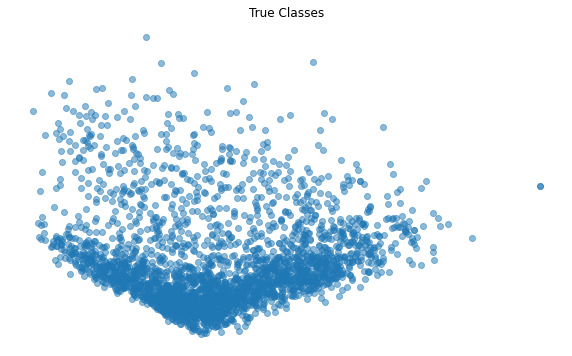

In [190]:
fig = plt.figure(figsize = (10,6))
ax = fig.add_subplot(111)
ax.set_frame_on(False)
ax.scatter(reduced_data[:, 0], reduced_data[:, 1], alpha = 0.5, label = colors)
plt.xticks(())
plt.yticks(())
plt.title('True Classes')
plt.show()

In [139]:
numClusters = 3

In [140]:
km = sklearn.cluster.KMeans(n_clusters=numClusters, init='k-means++')

In [180]:
km3 = sklearn.cluster.KMeans(n_clusters= 3, init='k-means++')
km3.fit(newsgroupsTFVects.toarray())

KMeans(n_clusters=3)

# Word Embedding

In [234]:
#All these packages need to be installed from pip
import gensim#For word2vec, etc
import requests #For downloading our datasets
import lucem_illud #pip install -U git+git://github.com/UChicago-Computational-Content-Analysis/lucem_illud.git

import numpy as np #For arrays
import pandas #Gives us DataFrames
import matplotlib.pyplot as plt #For graphics
import seaborn #Makes the graphics look nicer
import sklearn.metrics.pairwise #For cosine similarity
import sklearn.manifold #For T-SNE
import sklearn.decomposition #For PCA

#This 'magic' command makes the plots work better
#in the notebook, don't use it outside of a notebook.
#Also you can ignore the warning
%matplotlib inline

import os #For looking through files
import os.path #For managing file paths

In [7]:
data_past = "C:/Users/Louisa Zhao/Desktop/CORD/3/metadata.csv"

In [235]:
df_past = pd.read_csv(data_past)
df_past.head()

C:\Users\Louisa Zhao\AppData\Local\Programs\Python\Python39\lib\site-packages\IPython\core\interactiveshell.py:3146: DtypeWarning: Columns (1,4,5,6,13,14,15,16) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


,cord_uid,sha,source_x,title,doi,pmcid,pubmed_id,license,abstract,publish_time,authors,journal,mag_id,who_covidence_id,arxiv_id,pdf_json_files,pmc_json_files,url,s2_id
0,ug7v899j,d1aafb70c066a2068b02786f8929fd9c900897fb,PMC,Clinical features of culture-proven Mycoplasma...,10.1186/1471-2334-1-6,PMC35282,11472636,no-cc,OBJECTIVE: This retrospective chart review des...,2001-07-04,"Madani, Tariq A; Al-Ghamdi, Aisha A",BMC Infect Dis,NaN,NaN,NaN,document_parses/pdf_json/d1aafb70c066a2068b027...,document_parses/pmc_json/PMC35282.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3...,NaN
1,02tnwd4m,6b0567729c2143a66d737eb0a2f63f2dce2e5a7d,PMC,Nitric oxide: a pro-inflammatory mediator in l...,10.1186/rr14,PMC59543,11667967,no-cc,Inflammatory diseases of the respiratory tract...,2000-08-15,"Vliet, Albert van der; Eiserich, Jason P; Cros...",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/6b0567729c2143a66d737...,document_parses/pmc_json/PMC59543.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN
2,ejv2xln0,06ced00a5fc04215949aa72528f2eeaae1d58927,PMC,Surfactant protein-D and pulmonary host defense,10.1186/rr19,PMC59549,11667972,no-cc,Surfactant protein-D (SP-D) participates in th...,2000-08-25,"Crouch, Erika C",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/06ced00a5fc04215949aa...,document_parses/pmc_json/PMC59549.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN
3,2b73a28n,348055649b6b8cf2b9a376498df9bf41f7123605,PMC,Role of endothelin-1 in lung disease,10.1186/rr44,PMC59574,11686871,no-cc,Endothelin-1 (ET-1) is a 21 amino acid peptide...,2001-02-22,"Fagan, Karen A; McMurtry, Ivan F; Rodman, David M",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/348055649b6b8cf2b9a37...,document_parses/pmc_json/PMC59574.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN
4,9785vg6d,5f48792a5fa08bed9f56016f4981ae2ca6031b32,PMC,Gene expression in epithelial cells in respons...,10.1186/rr61,PMC59580,11686888,no-cc,Respiratory syncytial virus (RSV) and pneumoni...,2001-05-11,"Domachowske, Joseph B; Bonville, Cynthia A; Ro...",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/5f48792a5fa08bed9f560...,document_parses/pmc_json/PMC59580.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN


In [9]:
len(df_past)

44220

In [10]:
df_past['text'] = df_past['title'] + df_past['abstract']

In [15]:
df_past['text'] = df_past['text'].astype(str)

In [65]:
df_past_sample = df_past.sample(n=int(44220*0.1),random_state=1)

In [68]:
df_past_sample.index = range(0,len(df_past_sample))
df_past_sample

,sha,source_x,title,doi,pmcid,pubmed_id,license,abstract,publish_time,authors,journal,Microsoft Academic Paper ID,WHO #Covidence,has_full_text,full_text_file,text
0,NaN,PMC,Human ribosomal protein L13a is dispensable fo...,10.1261/rna.694007,PMC2080596,NaN,unk,"Previously, we demonstrated that treatment of ...",NaN,"Chaudhuri, Sujan; Vyas, Keyur; Kapasi, Purvi; ...",NaN,NaN,NaN,False,NaN,Human ribosomal protein L13a is dispensable fo...
1,23b23be9334b67bb1a8ebb240c51c112f8c6faec,Elsevier,Purification of recombinant nucleocapsid prote...,10.1016/j.pep.2005.06.015,NaN,16139513.0,els-covid,"Abstract In the present work, a single-step pu...",2006-03-31,"Tan, Yan Peng; Ling, Tau Chuan; Tan, Wen Siang...",Protein Expression and Purification,NaN,NaN,True,custom_license,Purification of recombinant nucleocapsid prote...
2,363a8d40fdc60c4d83d75c3144df1e49ea8f8102,Elsevier,Chapter 16 Eye and Associated Glands,10.1016/B978-0-12-391448-4.00016-2,NaN,NaN,els-covid,Abstract The eye is susceptible to adverse tox...,2018-12-31,"Dunn, Dale G.; Baker, Julia F.M.; Sorden, Stev...",Boorman's Pathology of the Rat,NaN,NaN,True,custom_license,Chapter 16 Eye and Associated GlandsAbstract T...
3,NaN,Elsevier,New Perspectives in Infectious Diseases,10.1016/j.cveq.2014.10.001,NaN,25441118.0,els-covid,NaN,2014-12-31,"Mealey, Robert H.",Veterinary Clinics of North America: Equine Pr...,NaN,NaN,False,custom_license,nan
4,NaN,PMC,The Utility of Preliminary Patient Evaluation ...,10.1093/ofid/ofx163.349,PMC5631788,NaN,cc-by-nc-nd,BACKGROUND: Acute respiratory illnesses are th...,2017 Oct 4,"Sik Kang, Jun; Yoon, Hee; Jhun, Byung Woo; Lim...",Open Forum Infect Dis,NaN,NaN,False,noncomm_use_subset,The Utility of Preliminary Patient Evaluation ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4417,afd02eef40ddcddd7af866ab707eb5f387cdb71a,Elsevier,"An efficient and tunable route to AG7088, a rh...",10.1016/j.tetlet.2004.08.179,NaN,NaN,els-covid,"Abstract Aldol reaction of N,N-dibenzyl valina...",2004-10-18,"Ma, Dawei; Xie, Weiqing; Zou, Bin; Lei, Qiong;...",Tetrahedron Letters,NaN,NaN,True,custom_license,"An efficient and tunable route to AG7088, a rh..."
4418,a526fb64b1ab4c06c7e5e1d484301b47498260e5,Elsevier,Rhinitis,10.1016/j.pop.2013.10.005,NaN,24439879.0,els-covid,NaN,2014-03-31,"Beard, Sheryl",Primary Care: Clinics in Office Practice,NaN,NaN,True,custom_license,nan
4419,NaN,biorxiv,Molecular mechanism of evolution and human inf...,10.1101/2020.02.17.952903,NaN,NaN,biorxiv,"Since December, 2019, an outbreak of pneumonia...",2020-02-21,"He, J.; Tao, H.; Yan, Y.; Huang, S.-Y.; Xiao, Y.",NaN,NaN,NaN,False,biorxiv_medrxiv,Molecular mechanism of evolution and human inf...
4420,437829e3b844b1cca575750a22807243e974dd21,Elsevier,Chapter 17 Transmission of infectious diseases...,10.1016/B978-0-323-02823-3.50022-X,NaN,NaN,els-covid,NaN,2005-12-31,"Lawrence, Robert M.",Breastfeeding,NaN,NaN,True,custom_license,nan


In [254]:
%%time
df_past_sample['tokenized_sents2'][3000:] = df_past_sample['text'][3000:].apply(lambda x: [lucem_illud.word_tokenize(s) for s in lucem_illud.sent_tokenize(x)])

Wall time: 1min 3s


<timed exec>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [259]:
%%time
df_past_sample['normalized_sents'][2000:] = df_past_sample['tokenized_sents2'][2000:].apply(lambda x: [lucem_illud.normalizeTokens(s) for s in x])

Wall time: 5.24 s


<timed exec>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [260]:
df_past_sample

,sha,source_x,title,doi,pmcid,pubmed_id,license,abstract,publish_time,authors,journal,Microsoft Academic Paper ID,WHO #Covidence,has_full_text,full_text_file,text,tokenized_sent,tokenized_sents2,normalized_sents
0,NaN,PMC,Human ribosomal protein L13a is dispensable fo...,10.1261/rna.694007,PMC2080596,NaN,unk,"Previously, we demonstrated that treatment of ...",NaN,"Chaudhuri, Sujan; Vyas, Keyur; Kapasi, Purvi; ...",NaN,NaN,NaN,False,NaN,Human ribosomal protein L13a is dispensable fo...,"[[human, ribosomal, protein, l13a, dispensable...","[[Human, ribosomal, protein, L13a, is, dispens...","[[human, ribosomal, protein, l13a, dispensable..."
1,23b23be9334b67bb1a8ebb240c51c112f8c6faec,Elsevier,Purification of recombinant nucleocapsid prote...,10.1016/j.pep.2005.06.015,NaN,16139513.0,els-covid,"Abstract In the present work, a single-step pu...",2006-03-31,"Tan, Yan Peng; Ling, Tau Chuan; Tan, Wen Siang...",Protein Expression and Purification,NaN,NaN,True,custom_license,Purification of recombinant nucleocapsid prote...,"[[purification, recombinant, nucleocapsid, pro...","[[Purification, of, recombinant, nucleocapsid,...","[[purification, recombinant, nucleocapsid, pro..."
2,363a8d40fdc60c4d83d75c3144df1e49ea8f8102,Elsevier,Chapter 16 Eye and Associated Glands,10.1016/B978-0-12-391448-4.00016-2,NaN,NaN,els-covid,Abstract The eye is susceptible to adverse tox...,2018-12-31,"Dunn, Dale G.; Baker, Julia F.M.; Sorden, Stev...",Boorman's Pathology of the Rat,NaN,NaN,True,custom_license,Chapter 16 Eye and Associated GlandsAbstract T...,"[[chapter, 16, eye, associated, glandsabstract...","[[Chapter, 16, Eye, and, Associated, GlandsAbs...","[[chapter, eye, associate, glandsabstract], [e..."
3,NaN,Elsevier,New Perspectives in Infectious Diseases,10.1016/j.cveq.2014.10.001,NaN,25441118.0,els-covid,NaN,2014-12-31,"Mealey, Robert H.",Veterinary Clinics of North America: Equine Pr...,NaN,NaN,False,custom_license,nan,[[nan]],[[nan]],[[nan]]
4,NaN,PMC,The Utility of Preliminary Patient Evaluation ...,10.1093/ofid/ofx163.349,PMC5631788,NaN,cc-by-nc-nd,BACKGROUND: Acute respiratory illnesses are th...,2017 Oct 4,"Sik Kang, Jun; Yoon, Hee; Jhun, Byung Woo; Lim...",Open Forum Infect Dis,NaN,NaN,False,noncomm_use_subset,The Utility of Preliminary Patient Evaluation ...,"[[the, utility, preliminary, patient, evaluati...","[[The, Utility, of, Preliminary, Patient, Eval...","[[utility, preliminary, patient, evaluation, f..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,f7bbdd316b8d64ca1001b67b96c06efd531893b6,PMC,Tools to Detect Influenza Virus,10.3349/ymj.2013.54.3.560,PMC3635619,23549796.0,cc-by-nc,"In 2009, pandemic influenza A (H1N1) virus (H1...",2013 May 1,"Kim, Dae-Ki; Poudel, Barun",Yonsei Med J,NaN,NaN,True,noncomm_use_subset,"Tools to Detect Influenza VirusIn 2009, pandem...","[[tools, detect, influenza, virusin, 2009, ,, ...","[[Tools, to, Detect, Influenza, VirusIn, 2009,...","[[tool, detect, influenza, virusin, pandemic, ..."
4996,1fceaf9f2102c71bf508ebd46c18c9b0cb48e6c3,PMC,"Morbidity, Mortality, and Seasonality of Influ...",10.1371/journal.pone.0161301,PMC5015910,27607330.0,cc0,BACKGROUND: Influenza typically comprises a su...,2016 Sep 8,"Kandeel, Amr; Dawson, Patrick; Labib, Manal; S...",PLoS One,NaN,NaN,True,comm_use_subset,"Morbidity, Mortality, and Seasonality of Influ...","[[morbidity, ,, mortality, ,, seasonality, inf...","[[Morbidity, Mortality, and, Seasonality, of, ...","[[morbidity, mortality, seasonality, influenza..."
4997,64a969ce0d6acc16005bedf8bf21a86b2c7f317f,Elsevier,Collectivités : lieu de rencontre virale,10.1016/j.reval.2014.01.018,NaN,NaN,els-covid,Résumé La répétition des épisodes infectieux c...,2014-04-30,"Brouard, J.; Vabret, A.; Dina, J.; Lemercier, H.",Revue Française d'Allergologie,NaN,NaN,True,custom_license,Collectivités : lieu de rencontre viraleRésumé...,"[[collectivités, :, lieu, de, rencontre, viral...","[[Collectivités, lieu, de, rencontre, viraleRé...","[[collectivité

In [236]:
text = df_past_sample['text'][10]
txt = word_tokenize(df_past_sample['text'][10])
normalizeTokens(txt)

' remarks protein attribute prediction pseudo amino acid compositionabstract accomplishment human genome sequencing number sequence-known proteins increased explosively contrast pace slower determining biological attributes consequence gap sequence-known proteins attribute-known proteins increasingly large unbalanced situation critically limited ability timely utilize newly discovered proteins basic research drug development called developing computational methods high-throughput automated tools fast reliably identifying attributes uncharacterized proteins based sequence information actually decades methods regard established hope bridge gap course developing methods following things needed consider benchmark dataset construction protein sample formulation operating algorithm engine anticipated accuracy web-server establishment review discuss procedures special focus introduction pseudo amino acid composition pseaac different modes applications recent development particularly use gener

In [237]:
df_past_sample['tokenized_sent'] = 1

In [238]:
for i in range(len(df_past_sample)):
    text = df_past_sample['text'][i]
    doc = nlp(text)
    tokens = [token.text for token in doc]
    tokens_without_sw= [word.lower() for word in tokens if not word in all_stopwords]
    df_past_sample['tokenized_sent'][i] = [tokens_without_sw]

<ipython-input-238-9e80bd6ccd41>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_past_sample['tokenized_sent'][i] = [tokens_without_sw]
C:\Users\Louisa Zhao\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\indexing.py:1636: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)


In [79]:
for i in range(len(df_past_sample)):
    text = df_past_sample['text'][i]
    doc = nlp(text)
    tokens = [token.text for token in doc]
    tokens_without_sw= [word.lower() for word in tokens if not word in all_stopwords]
    sentence = ''
    for t in tokens_without_sw:
        sentence = sentence + t +" "
    df_past_sample['tokenized_sent'][i] = sentence

<ipython-input-79-5b81b6c968b0>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_past_sample['tokenized_sent'][i] = sentence


In [239]:
df_process = df_past_sample[['tokenized_sent','doi']].dropna()

In [240]:
df_process

,tokenized_sent,doi
0,"[[human, ribosomal, protein, l13a, dispensable...",10.1261/rna.694007
1,"[[purification, recombinant, nucleocapsid, pro...",10.1016/j.pep.2005.06.015
2,"[[chapter, 16, eye, associated, glandsabstract...",10.1016/B978-0-12-391448-4.00016-2
3,[[nan]],10.1016/j.cveq.2014.10.001
4,"[[the, utility, preliminary, patient, evaluati...",10.1093/ofid/ofx163.349
...,...,...
4994,"[[antifragility, tinkering, biology, (, busine...",10.3390/genes2040998
4995,"[[tools, detect, influenza, virusin, 2009, ,, ...",10.3349/ymj.2013.54.3.560
4996,"[[morbidity, ,, mortality, ,, seasonality, inf...",10.1371/journal.pone.0161301
4997,"[[collectivités, :, lieu, de, rencontre, viral...",10.1016/j.reval.2014.01.018


In [580]:
senReleasesW2V_past = gensim.models.word2vec.Word2Vec(df_process['tokenized_sent'].sum())

In [242]:
senReleasesW2V_past.wv.syn0

array([[-0.2652962 , -0.59577024, -1.1157467 , ..., -0.36237052,
         0.67834204,  0.2026669 ],
       [ 0.03794899,  0.34109563, -0.09802619, ...,  0.6100485 ,
         0.09602518,  0.6848686 ],
       [ 1.4380563 , -0.7612137 ,  0.13513096, ...,  0.8294257 ,
         0.76796544,  0.6223809 ],
       ...,
       [-0.00976761,  0.00555668, -0.03058692, ...,  0.00352319,
        -0.02097772, -0.00740287],
       [ 0.01047004, -0.01906467, -0.03767239, ...,  0.00470029,
        -0.00824941,  0.04088879],
       [ 0.01369912, -0.0481083 , -0.03310684, ...,  0.01744423,
         0.00630515,  0.03676027]], dtype=float32)

In [243]:
senReleasesW2V_past.wv.index2word[100]

'years'

In [246]:
senReleasesW2V_past.most_similar('coronavirus',topn=50)

[('sars-associated', 0.943769097328186),
 ('cov', 0.9260380268096924),
 ('syndrome', 0.8733928799629211),
 ('mers-cov', 0.8444339036941528),
 ('virusthe', 0.8309320211410522),
 ('sars-cov', 0.8275927305221558),
 ('coronaviruses', 0.8240538835525513),
 ('sars', 0.8118820190429688),
 ('east', 0.8117488026618958),
 ('porcine', 0.8107038140296936),
 ('229e', 0.8067304491996765),
 ('deltacoronavirus', 0.8020702600479126),
 ('middle', 0.7996852397918701),
 ('lopinavir', 0.798172116279602),
 ('reproductive', 0.7897120118141174),
 ('canine', 0.7877308130264282),
 ('syndrome-associated', 0.787466287612915),
 ('torovirus', 0.787369966506958),
 ('pedv', 0.7826090455055237),
 ('2019-ncov', 0.7789957523345947),
 ('bat', 0.7778565883636475),
 ('emerged', 0.7753978967666626),
 ('gastroenteritis', 0.7722688913345337),
 ('covs', 0.7721377611160278),
 ('transmissible', 0.7720420360565186),
 ('betacoronavirus', 0.7684488296508789),
 ('circovirus', 0.7599955797195435),
 ('nl63', 0.7591556310653687),
 ('bo

In [210]:
senReleasesW2V.most_similar('covid')

[('lived', 0.9876450300216675),
 ('beginning', 0.9822872877120972),
 ('persons', 0.9788972735404968),
 ('kingdom', 0.9770923852920532),
 ('experiencing', 0.9759516716003418),
 ('republic', 0.9755035638809204),
 ('rural', 0.9752160310745239),
 ('referred', 0.9751484394073486),
 ('province', 0.9743338823318481),
 ('began', 0.9736824035644531)]

In [607]:
senReleasesW2V.most_similar('covid-19',topn=30)

[('sick', 0.7366543412208557),
 ('millions', 0.7090441584587097),
 ('caring', 0.7056304216384888),
 ('immunosuppressed', 0.6958492994308472),
 ('CoVID-19', 0.6949954032897949),
 ('contacts', 0.6831305623054504),
 ("n't", 0.6754666566848755),
 ('actively', 0.6722036004066467),
 ('caregivers', 0.6705849170684814),
 ('merit', 0.670103907585144),
 ('acquiring', 0.6652376651763916),
 ('catastrophic', 0.6649147272109985),
 ('quarantined', 0.6646639108657837),
 ('therapeutically', 0.6615302562713623),
 ('deprived', 0.6595646142959595),
 ('eldercare', 0.65706467628479),
 ('overwhelmed', 0.6520928144454956),
 ('families', 0.6518652439117432),
 ('suffer', 0.650672197341919),
 ('thousands', 0.6480980515480042),
 ('disabilities', 0.6471385359764099),
 ('others', 0.6461302042007446),
 ('measles', 0.645499587059021),
 ('AECOPD', 0.6445110440254211),
 ('nonsevere', 0.6440349817276001),
 ('HCP', 0.6428908109664917),
 ('warnings', 0.6378694772720337),
 ('Israeli', 0.6376818418502808),
 ('COVID-19-infec

In [582]:
senReleasesW2V.most_similar('cell')

[('cells', 0.8826916217803955),
 ('T', 0.8688819408416748),
 ('proliferation', 0.8189815282821655),
 ('stem', 0.8184915781021118),
 ('tissues', 0.8180201053619385),
 ('macrophages', 0.8060121536254883),
 ('epithelial', 0.783216118812561),
 ('antigen', 0.7788147926330566),
 ('migration', 0.7742949724197388),
 ('tumor', 0.7714114189147949)]

In [581]:
senReleasesW2V.most_similar('protein')

[('binding', 0.947868824005127),
 ('peptide', 0.9311283826828003),
 ('gene', 0.9310747385025024),
 ('protease', 0.910786509513855),
 ('domain', 0.9013420343399048),
 ('receptor', 0.9011743664741516),
 ('glycoprotein', 0.8964095711708069),
 ('enzyme', 0.8953102827072144),
 ('mRNA', 0.8879732489585876),
 ('recombinant', 0.8846875429153442)]

In [453]:
senReleasesW2V.most_similar('pcr',topn=40)

[('passaged', 0.9700897932052612),
 ('mhv', 0.9672999382019043),
 ('pedv', 0.9662164449691772),
 ('vesicular', 0.9654030799865723),
 ('adenovirus', 0.9629119634628296),
 ('vaccinated', 0.960747241973877),
 ('isolated', 0.9606490135192871),
 ('feces', 0.95943284034729),
 ('nidovirus', 0.9594202041625977),
 ('simplex', 0.9592021107673645),
 ('balb/c', 0.9587736129760742),
 ('igg', 0.9583846926689148),
 ('humanized', 0.9573121070861816),
 ('iav', 0.9568504691123962),
 ('qrt-pcr', 0.9559948444366455),
 ('diseased', 0.9554423093795776),
 ('supernatant', 0.9550571441650391),
 ('adv', 0.9546603560447693),
 ('b.', 0.9542218446731567),
 ('genotype', 0.9539303779602051),
 ('mabs', 0.9539018869400024),
 ('immunofluorescence', 0.9536819458007812),
 ('vsv', 0.9533970355987549),
 ('ns1', 0.952776312828064),
 ('non-structural', 0.952642560005188),
 ('bfa', 0.9526271224021912),
 ('knockout', 0.9514034986495972),
 ('serotypes', 0.9511868953704834),
 ('titers', 0.9510560035705566),
 ('stomatitis', 0.951

In [120]:
senReleasesW2V.doesnt_match(['coronavirus', 'covid19', 'virus'])

'covid19'

In [121]:
senReleasesW2V.save("senpressreleasesWORD2Vec")

In [126]:
numWords = 100
targetWords = senReleasesW2V.wv.index2word[:numWords]

In [127]:
wordsSubMatrix = []
for word in targetWords:
    wordsSubMatrix.append(senReleasesW2V[word])
wordsSubMatrix = np.array(wordsSubMatrix)
wordsSubMatrix

array([[ 0.19622725, -0.80337465, -1.1353912 , ..., -0.49843934,
         0.40499178, -0.09996635],
       [ 0.18438655,  0.17964219, -0.5085682 , ...,  0.49895254,
         0.5454675 ,  0.35941103],
       [ 1.133071  , -0.29902005,  0.860451  , ...,  0.96534187,
         1.14054   , -0.1908367 ],
       ...,
       [ 1.3869133 , -0.37772897,  0.15245366, ...,  1.3889512 ,
         0.9331608 ,  1.1369933 ],
       [ 0.59836656, -0.4782161 , -0.18050629, ...,  0.9542079 ,
         0.2927131 ,  0.6570426 ],
       [ 1.5990673 , -1.0358005 , -0.41216972, ...,  1.0680518 ,
         0.6388368 ,  0.65352803]], dtype=float32)

In [128]:
pcaWords = sklearn.decomposition.PCA(n_components = 100).fit(wordsSubMatrix)
reducedPCA_data = pcaWords.transform(wordsSubMatrix)
#T-SNE is theoretically better, but you should experiment
tsneWords = sklearn.manifold.TSNE(n_components = 2).fit_transform(reducedPCA_data)

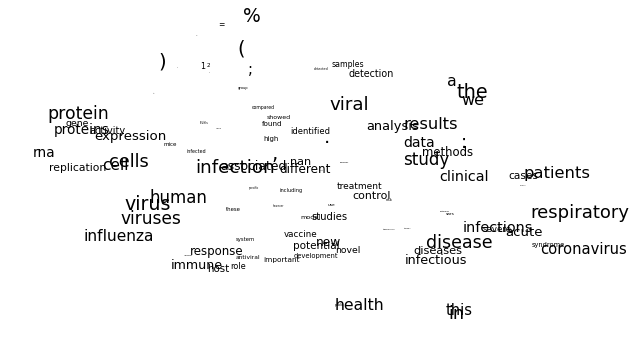

In [129]:
fig = plt.figure(figsize = (10,6))
ax = fig.add_subplot(111)
ax.set_frame_on(False)
plt.scatter(tsneWords[:, 0], tsneWords[:, 1], alpha = 0)#Making the points invisible 
for i, word in enumerate(targetWords):
    ax.annotate(word, (tsneWords[:, 0][i],tsneWords[:, 1][i]), size =  20 * (numWords - i) / numWords)
plt.xticks(())
plt.yticks(())
plt.show()

In [261]:
senReleasesW2V_past2 = gensim.models.word2vec.Word2Vec(df_past_sample['normalized_sents'].sum())

In [263]:
senReleasesW2V_past2.wv.syn0

array([[ 0.7340308 ,  0.66614467, -0.73214394, ..., -0.86579365,
         0.52810955, -0.53146315],
       [-0.3669198 , -0.30184662, -0.41632012, ...,  0.4229193 ,
         0.24545127,  0.6297337 ],
       [-0.14191292, -0.22281644,  0.22848323, ...,  0.4974588 ,
         0.6272297 , -0.44500333],
       ...,
       [-0.01330245, -0.01606619, -0.06324165, ...,  0.05261237,
        -0.00139876, -0.03501707],
       [-0.01479107, -0.02653398, -0.04851815, ...,  0.01925735,
        -0.0018193 , -0.02548954],
       [-0.01271327, -0.04559273, -0.06008062, ...,  0.06974807,
         0.00435042, -0.04104434]], dtype=float32)

In [265]:
senReleasesW2V_past2.wv.index2word[10]

'patient'

In [269]:
senReleasesW2V_past2.most_similar('coronavirus',topn=20)

[('covs', 0.9185484051704407),
 ('nl63', 0.8919076919555664),
 ('hcov', 0.8865175843238831),
 ('oc43', 0.8771578669548035),
 ('coronavirusabstract', 0.8756288886070251),
 ('229e', 0.8668340444564819),
 ('entryabstract', 0.8574645519256592),
 ('mink', 0.8467388153076172),
 ('emc', 0.8417843580245972),
 ('bat', 0.8267830014228821),
 ('pseudovirus', 0.8257812261581421),
 ('hcov-229e', 0.8169622421264648),
 ('hku1', 0.8123912215232849),
 ('recently', 0.8117558360099792),
 ('porcine', 0.8079896569252014),
 ('deltacoronavirus', 0.8072450160980225),
 ('sarsr', 0.8052161931991577),
 ('transmissible', 0.8045700192451477),
 ('orthoreoviruses', 0.8000831604003906),
 ('east', 0.7971597909927368)]

In [444]:
numWords = 50
targetWords_2 = senReleasesW2V_past2.wv.index2word[:numWords]

In [445]:
wordsSubMatrix_2 = []
for word in targetWords_2:
    wordsSubMatrix_2.append(senReleasesW2V_past2[word])
wordsSubMatrix_2 = np.array(wordsSubMatrix_2)
wordsSubMatrix_2

array([[ 0.7340308 ,  0.66614467, -0.73214394, ..., -0.86579365,
         0.52810955, -0.53146315],
       [-0.3669198 , -0.30184662, -0.41632012, ...,  0.4229193 ,
         0.24545127,  0.6297337 ],
       [-0.14191292, -0.22281644,  0.22848323, ...,  0.4974588 ,
         0.6272297 , -0.44500333],
       ...,
       [ 2.6491072 ,  0.5996217 , -0.93377745, ...,  0.11619437,
         0.77296233, -1.2641716 ],
       [ 0.6024387 ,  1.2994673 , -1.5256895 , ..., -0.11928102,
        -0.496717  ,  0.38053033],
       [-0.04992687, -0.38985163, -0.5210535 , ...,  2.1766734 ,
         0.44799232,  0.38256872]], dtype=float32)

In [446]:
pcaWords2 = sklearn.decomposition.PCA(n_components = 50).fit(wordsSubMatrix_2)
reducedPCA_data2 = pcaWords.transform(wordsSubMatrix_2)
#T-SNE is theoretically better, but you should experiment
tsneWords2 = sklearn.manifold.TSNE(n_components = 2).fit_transform(reducedPCA_data)

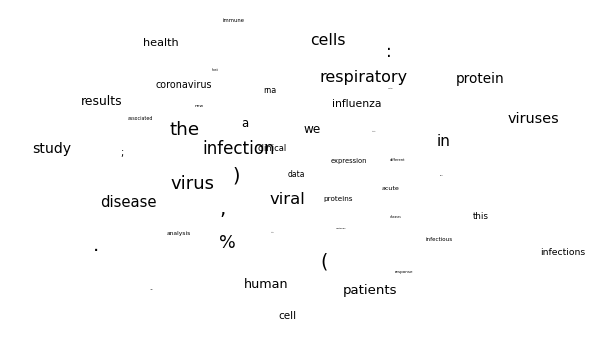

In [447]:
fig = plt.figure(figsize = (10,6))
ax = fig.add_subplot(111)
ax.set_frame_on(False)
plt.scatter(tsneWords2[:, 0], tsneWords2[:, 1], alpha = 0)#Making the points invisible 
for i, word in enumerate(targetWords):
    ax.annotate(word, (tsneWords2[:, 0][i],tsneWords2[:, 1][i]), size =  20 * (numWords - i) / numWords)
plt.xticks(())
plt.yticks(())
plt.show()

In [307]:
from sklearn.manifold import TSNE

In [308]:
def tsne_plot(model):
    "Creates and TSNE model and plots it"
    labels = []
    tokens = []

    for word in model.wv.vocab:
        tokens.append(model[word])
        labels.append(word)
    
    tsne_model = TSNE(perplexity=40, n_components=2, init='pca', n_iter=2500, random_state=23)
    new_values = tsne_model.fit_transform(tokens)

    x = []
    y = []
    for value in new_values:
        x.append(value[0])
        y.append(value[1])
        
    plt.figure(figsize=(16, 16)) 
    for i in range(len(x)):
        plt.scatter(x[i],y[i])
        plt.annotate(labels[i],
                     xy=(x[i], y[i]),
                     xytext=(5, 2),
                     textcoords='offset points',
                     ha='right',
                     va='bottom')
    plt.show()

# Word Embedding for Jan 2021 data

In [132]:
data_now = "C:/Users/Louisa Zhao/Desktop/CORD/11/metadata.csv"

In [145]:
df_now = pd.read_csv(data_now,nrows=100000)
df_now_total = df_now[['title','abstract']]

C:\Users\Louisa Zhao\AppData\Local\Programs\Python\Python39\lib\site-packages\IPython\core\interactiveshell.py:3146: DtypeWarning: Columns (1,5,6,15,16) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


In [325]:
df_now['Year'] = df_now['publish_time']

In [330]:
df_now['Year'] = [x[:4] for x in df_now['publish_time']]
df_now

,cord_uid,sha,source_x,title,doi,pmcid,pubmed_id,license,abstract,publish_time,authors,journal,mag_id,who_covidence_id,arxiv_id,pdf_json_files,pmc_json_files,url,s2_id,Year
0,ug7v899j,d1aafb70c066a2068b02786f8929fd9c900897fb,PMC,Clinical features of culture-proven Mycoplasma...,10.1186/1471-2334-1-6,PMC35282,11472636,no-cc,OBJECTIVE: This retrospective chart review des...,2001-07-04,"Madani, Tariq A; Al-Ghamdi, Aisha A",BMC Infect Dis,NaN,NaN,NaN,document_parses/pdf_json/d1aafb70c066a2068b027...,document_parses/pmc_json/PMC35282.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3...,NaN,2001
1,02tnwd4m,6b0567729c2143a66d737eb0a2f63f2dce2e5a7d,PMC,Nitric oxide: a pro-inflammatory mediator in l...,10.1186/rr14,PMC59543,11667967,no-cc,Inflammatory diseases of the respiratory tract...,2000-08-15,"Vliet, Albert van der; Eiserich, Jason P; Cros...",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/6b0567729c2143a66d737...,document_parses/pmc_json/PMC59543.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN,2000
2,ejv2xln0,06ced00a5fc04215949aa72528f2eeaae1d58927,PMC,Surfactant protein-D and pulmonary host defense,10.1186/rr19,PMC59549,11667972,no-cc,Surfactant protein-D (SP-D) participates in th...,2000-08-25,"Crouch, Erika C",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/06ced00a5fc04215949aa...,document_parses/pmc_json/PMC59549.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN,2000
3,2b73a28n,348055649b6b8cf2b9a376498df9bf41f7123605,PMC,Role of endothelin-1 in lung disease,10.1186/rr44,PMC59574,11686871,no-cc,Endothelin-1 (ET-1) is a 21 amino acid peptide...,2001-02-22,"Fagan, Karen A; McMurtry, Ivan F; Rodman, David M",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/348055649b6b8cf2b9a37...,document_parses/pmc_json/PMC59574.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN,2001
4,9785vg6d,5f48792a5fa08bed9f56016f4981ae2ca6031b32,PMC,Gene expression in epithelial cells in respons...,10.1186/rr61,PMC59580,11686888,no-cc,Respiratory syncytial virus (RSV) and pneumoni...,2001-05-11,"Domachowske, Joseph B; Bonville, Cynthia A; Ro...",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/5f48792a5fa08bed9f560...,document_parses/pmc_json/PMC59580.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN,2001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,p9te6wlu,NaN,Medline,Mechanisms of Action of Novel Influenza A/M2 V...,10.1124/mol.115.102731,NaN,27193582,unk,The increasing prevalence of influenza viruses...,2016,"Jalily, Pouria H; Eldstrom, Jodene; Miller, Sc...",Molecular pharmacology,NaN,NaN,NaN,NaN,NaN,https://doi.org/10.1124/mol.115.102731; https:...,9696564.0,2016
99996,be1sh3g9,NaN,Medline,"Benchtop study of leakages across the Portex, ...",10.12809/hkmj133930,NaN,23878202,cc-by-nc-nd,OBJECTIVES. To compare three endotracheal tube...,2014,"Lau, Arthur C W; Lam, S M; Yan, W W",Hong Kong medical journal = Xianggang yi xue z...,NaN,NaN,NaN,NaN,NaN,https://doi.org/10.12809/hkmj133930; https://w...,38006158.0,2014
99997,70zflr06,NaN,Medline,Emergency Radiology in 2020: Moving Forward To...,10.1177/0846537120918954,NaN,32272845,unk,NaN,2020-04-10,"Redmond, Ciaran E; Gibney, Brian; Nicolaou, Sa...",Canadian Association of Radiologists journal =...,NaN,NaN,NaN,NaN,NaN,https://doi.org/10.1177/0846537120918954; http...,215727172.0,2020
99998,122wqzhm,NaN,Medline,[Detección y caracterización molecular de viru...,10.24875/gmm.19005138,NaN,31182877,unk,Introduction Acute respiratory infections are ...,2019,"Díaz-Chiguer, Dylan Lucía; Tirado-Mendoza, Roc...",Gaceta medica de Mexico,NaN,NaN,NaN,NaN,NaN,https://doi.org/10.24875/gmm.19005138; https:/...,184485145.0,2019


In [331]:
df_now_total = df_now[['title','abstract','Year']]
df_now_total

,title,abstract,Year
0,Clinical features of culture-proven Mycoplasma...,OBJECTIVE: This retrospective chart review des...,2001
1,Nitric oxide: a pro-inflammatory mediator in l...,Inflammatory diseases of the respiratory tract...,2000
2,Surfactant protein-D and pulmonary host defense,Surfactant protein-D (SP-D) participates in th...,2000
3,Role of endothelin-1 in lung disease,Endothelin-1 (ET-1) is a 21 amino acid peptide...,2001
4,Gene expression in epithelial cells in respons...,Respiratory syncytial virus (RSV) and pneumoni...,2001
...,...,...,...
99995,Mechanisms of Action of Novel Influenza A/M2 V...,The increasing prevalence of influenza viruses...,2016
99996,"Benchtop study of leakages across the Portex, ...",OBJECTIVES. To compare three endotracheal tube...,2014
99997,Emergency Radiology in 2020: Moving Forward To...,NaN,2020
99998,[Detección y caracterización molecular de viru...,Introduction Acute respiratory infections are ...,2019


In [335]:
df_now_total['text'] = df_now_total['title'] + df_now_total['abstract']

<ipython-input-335-2563c587c0be>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_now_total['text'] = df_now_total['title'] + df_now_total['abstract']


In [336]:
df_now_total

,title,abstract,Year,text
0,Clinical features of culture-proven Mycoplasma...,OBJECTIVE: This retrospective chart review des...,2001,Clinical features of culture-proven Mycoplasma...
1,Nitric oxide: a pro-inflammatory mediator in l...,Inflammatory diseases of the respiratory tract...,2000,Nitric oxide: a pro-inflammatory mediator in l...
2,Surfactant protein-D and pulmonary host defense,Surfactant protein-D (SP-D) participates in th...,2000,Surfactant protein-D and pulmonary host defens...
3,Role of endothelin-1 in lung disease,Endothelin-1 (ET-1) is a 21 amino acid peptide...,2001,Role of endothelin-1 in lung diseaseEndothelin...
4,Gene expression in epithelial cells in respons...,Respiratory syncytial virus (RSV) and pneumoni...,2001,Gene expression in epithelial cells in respons...
...,...,...,...,...
99995,Mechanisms of Action of Novel Influenza A/M2 V...,The increasing prevalence of influenza viruses...,2016,Mechanisms of Action of Novel Influenza A/M2 V...
99996,"Benchtop study of leakages across the Portex, ...",OBJECTIVES. To compare three endotracheal tube...,2014,"Benchtop study of leakages across the Portex, ..."
99997,Emergency Radiology in 2020: Moving Forward To...,NaN,2020,NaN
99998,[Detección y caracterización molecular de viru...,Introduction Acute respiratory infections are ...,2019,[Detección y caracterización molecular de viru...


In [337]:
df_now_total['text'] = df_now_total['text'].astype(str)

<ipython-input-337-a28ea0c1bc1e>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_now_total['text'] = df_now_total['text'].astype(str)


In [348]:
df_now_sample = df_now_total.sample(n=int(len(df_now_total)*0.1),random_state=1)

In [349]:
df_now_sample.index = range(0,len(df_now_sample))
df_now_sample

,title,abstract,Year,text
0,Modified Isolation Selective Cerebral Perfusio...,Isolation selective cerebral perfusion (ISCP) ...,2019,Modified Isolation Selective Cerebral Perfusio...
1,COVID-19 pandemic: Are we witnessing the first...,NaN,2020,nan
2,Note from the editors: Eurosurveillance contri...,NaN,2020,nan
3,Changes in glucose-6-phosphate dehydrogenase e...,Hepatocellular carcinoma (HCC) is regarded as ...,2014,Changes in glucose-6-phosphate dehydrogenase e...
4,Abstracts from the 6th Annual Congress of the ...,Abstracts from the 6th Annual Congress of the ...,2017,Abstracts from the 6th Annual Congress of the ...
...,...,...,...,...
9995,Covid:19: Italy has wasted the sacrifices of t...,NaN,2020,nan
9996,Tomographic Measurement of Gutters and Analysi...,BACKGROUND The Octopus technique is an off-lab...,2016,Tomographic Measurement of Gutters and Analysi...
9997,Birth and pathogenesis of rogue respiratory vi...,Emerging infectious diseases of zoonotic origi...,2015,Birth and pathogenesis of rogue respiratory vi...
9998,Effect of Jinhua Qinggan granules on novel cor...,OBJECTIVE To evaluate the effectiveness and sa...,2020,Effect of Jinhua Qinggan granules on novel cor...


In [350]:
df_process_new = df_now_sample[['text','abstract','Year','title']].dropna()
df_process_new

,text,abstract,Year,title
0,Modified Isolation Selective Cerebral Perfusio...,Isolation selective cerebral perfusion (ISCP) ...,2019,Modified Isolation Selective Cerebral Perfusio...
3,Changes in glucose-6-phosphate dehydrogenase e...,Hepatocellular carcinoma (HCC) is regarded as ...,2014,Changes in glucose-6-phosphate dehydrogenase e...
4,Abstracts from the 6th Annual Congress of the ...,Abstracts from the 6th Annual Congress of the ...,2017,Abstracts from the 6th Annual Congress of the ...
5,High-level Expression of the ORF6 Gene of Porc...,High-level expression of the ORF6 gene of porc...,2003,High-level Expression of the ORF6 Gene of Porc...
7,Perioperative management for patients with cor...,The coronavirus disease 2019 (COVID-19) is a n...,2020,Perioperative management for patients with cor...
...,...,...,...,...
9994,BET 1: Prone positioning of awake patients wit...,A short-cut review of the literature was carri...,2020,BET 1: Prone positioning of awake patients wit...
9996,Tomographic Measurement of Gutters and Analysi...,BACKGROUND The Octopus technique is an off-lab...,2016,Tomographic Measurement of Gutters and Analysi...
9997,Birth and pathogenesis of rogue respiratory vi...,Emerging infectious diseases of zoonotic origi...,2015,Birth and pathogenesis of rogue respiratory vi...
9998,Effect of Jinhua Qinggan granules on novel cor...,OBJECTIVE To evaluate the effectiveness and sa...,2020,Effect of Jinhua Qinggan granules on novel cor...


In [356]:
%%time
df_process_new['tokenized_sents'][4000:] = df_process_new['text'][4000:].apply(lambda x: [lucem_illud.word_tokenize(s) for s in lucem_illud.sent_tokenize(x)])

Wall time: 1min 51s


In [358]:
%%time
df_process_new['normalized_sents'] = df_process_new['tokenized_sents'].apply(lambda x: [lucem_illud.normalizeTokens(s) for s in x])

Wall time: 24.6 s


In [359]:
df_process_new

,text,abstract,Year,title,tokenized_sents,normalized_sents
0,Modified Isolation Selective Cerebral Perfusio...,Isolation selective cerebral perfusion (ISCP) ...,2019,Modified Isolation Selective Cerebral Perfusio...,"[[Modified, Isolation, Selective, Cerebral, Pe...","[[modify, isolation, selective, cerebral, perf..."
3,Changes in glucose-6-phosphate dehydrogenase e...,Hepatocellular carcinoma (HCC) is regarded as ...,2014,Changes in glucose-6-phosphate dehydrogenase e...,"[[Changes, in, glucose-6-phosphate, dehydrogen...","[[change, glucose-6-phosphate, dehydrogenase, ..."
4,Abstracts from the 6th Annual Congress of the ...,Abstracts from the 6th Annual Congress of the ...,2017,Abstracts from the 6th Annual Congress of the ...,"[[Abstracts, from, the, 6th, Annual, Congress,...","[[abstract, annual, congress, association, vas..."
5,High-level Expression of the ORF6 Gene of Porc...,High-level expression of the ORF6 gene of porc...,2003,High-level Expression of the ORF6 Gene of Porc...,"[[High, level, Expression, of, the, ORF6, Gene...","[[high, level, expression, orf6, gene, porcine..."
7,Perioperative management for patients with cor...,The coronavirus disease 2019 (COVID-19) is a n...,2020,Perioperative management for patients with cor...,"[[Perioperative, management, for, patients, wi...","[[perioperative, management, patient, coronavi..."
...,...,...,...,...,...,...
9994,BET 1: Prone positioning of awake patients wit...,A short-cut review of the literature was carri...,2020,BET 1: Prone positioning of awake patients wit...,"[[BET, 1], [Prone, positioning, of, awake, pat...","[[bet], [prone, position, awake, patient, acut..."
9996,Tomographic Measurement of Gutters and Analysi...,BACKGROUND The Octopus technique is an off-lab...,2016,Tomographic Measurement of Gutters and Analysi...,"[[Tomographic, Measurement, of, Gutters, and, ...","[[tomographic, measurement, gutter, analysis, ..."
9997,Birth and pathogenesis of rogue respiratory vi...,Emerging infectious diseases of zoonotic origi...,2015,Birth and pathogenesis of rogue respiratory vi...,"[[Birth, and, pathogenesis, of, rogue, respira...","[[birth, pathogenesis, rogue, respiratory, vir..."
9998,Effect of Jinhua Qinggan granules on novel cor...,OBJECTIVE To evaluate the effectiveness and sa...,2020,Effect of Jinhua Qinggan granules on novel cor...,"[[Effect, of, Jinhua, Qinggan, granules, on, n...","[[effect, jinhua, qinggan, granule, novel, cor..."


In [200]:
df_process_new.index = range(0,len(df_process_new))
df_process_new

,text,abstract,title,tokenized_sent
0,Modified Isolation Selective Cerebral Perfusio...,Isolation selective cerebral perfusion (ISCP) ...,Modified Isolation Selective Cerebral Perfusio...,"[[modified, isolation, selective, cerebral, pe..."
1,Changes in glucose-6-phosphate dehydrogenase e...,Hepatocellular carcinoma (HCC) is regarded as ...,Changes in glucose-6-phosphate dehydrogenase e...,1
2,Abstracts from the 6th Annual Congress of the ...,Abstracts from the 6th Annual Congress of the ...,Abstracts from the 6th Annual Congress of the ...,1
3,High-level Expression of the ORF6 Gene of Porc...,High-level expression of the ORF6 gene of porc...,High-level Expression of the ORF6 Gene of Porc...,1
4,Perioperative management for patients with cor...,The coronavirus disease 2019 (COVID-19) is a n...,Perioperative management for patients with cor...,1
...,...,...,...,...
3521,Megaprosthesis in distal femur nonunions in el...,PURPOSE OF THE STUDY: To evaluate the outcomes...,Megaprosthesis in distal femur nonunions in el...,1
3522,Hand-assisted laparoscopic donor nephrectomy: ...,INTRODUCTION The advantages of a minimally inv...,Hand-assisted laparoscopic donor nephrectomy: ...,1
3523,Primary intestinal follicular lymphoma present...,Multiple lymphomatous polyposis (MLP) is a rar...,Primary intestinal follicular lymphoma present...,1
3524,Factors associated with a SARS-CoV-2 recurrenc...,Background: The proportion of recurrences afte...,Factors associated with a SARS-CoV-2 recurrenc...,1


In [201]:
for i in range(len(df_process_new)):
    text = df_process_new['text'][i]
    doc = nlp(text)
    tokens = [token.text for token in doc]
    tokens_without_sw= [word.lower() for word in tokens if not word in all_stopwords]
    df_process_new['tokenized_sent'][i] = [tokens_without_sw]

In [559]:
df_process_new[:20]

,text,abstract,Year,title,tokenized_sents,normalized_sents
0,Modified Isolation Selective Cerebral Perfusio...,Isolation selective cerebral perfusion (ISCP) ...,2019,Modified Isolation Selective Cerebral Perfusio...,"[[Modified, Isolation, Selective, Cerebral, Pe...","[[modify, isolation, selective, cerebral, perf..."
3,Changes in glucose-6-phosphate dehydrogenase e...,Hepatocellular carcinoma (HCC) is regarded as ...,2014,Changes in glucose-6-phosphate dehydrogenase e...,"[[Changes, in, glucose-6-phosphate, dehydrogen...","[[change, glucose-6-phosphate, dehydrogenase, ..."
4,Abstracts from the 6th Annual Congress of the ...,Abstracts from the 6th Annual Congress of the ...,2017,Abstracts from the 6th Annual Congress of the ...,"[[Abstracts, from, the, 6th, Annual, Congress,...","[[abstract, annual, congress, association, vas..."
5,High-level Expression of the ORF6 Gene of Porc...,High-level expression of the ORF6 gene of porc...,2003,High-level Expression of the ORF6 Gene of Porc...,"[[High, level, Expression, of, the, ORF6, Gene...","[[high, level, expression, orf6, gene, porcine..."
7,Perioperative management for patients with cor...,The coronavirus disease 2019 (COVID-19) is a n...,2020,Perioperative management for patients with cor...,"[[Perioperative, management, for, patients, wi...","[[perioperative, management, patient, coronavi..."
8,Possible Radio Interference Between Video Caps...,Video capsule endoscopy (VCE) is a noninvasive...,2016,Possible Radio Interference Between Video Caps...,"[[Possible, Radio, Interference, Between, Vide...","[[possible, radio, interference, video, capsul..."
9,Lipid moieties of Mycoplasma pneumoniae lipopr...,Vaccine-enhanced disease (VED) occurs as a res...,2020,Lipid moieties of Mycoplasma pneumoniae lipopr...,"[[Lipid, moieties, of, Mycoplasma, pneumoniae,...","[[lipid, moiety, mycoplasma, pneumonia, lipopr..."
10,"1,3-Propanediol production from glycerol in po...",The use of batch and upflow anaerobic reactors...,2020,"1,3-Propanediol production from glycerol in po...","[[1,3-Propanediol, production, from, glycerol,...","[[1,3-propanediol, production, glycerol, polyu..."
11,Disability Rights as a Necessary Framework for...,"In this essay, we suggest practical ways to sh...",2020,Disability Rights as a Necessary Framework for...,"[[Disability, Rights, as, a, Necessary, Framew...","[[disability, right, necessary, framework, cri..."
12,End-of-life care preferences of older patients...,INTRODUCTION End-of-life care is an essential ...,2020,End-of-life care preferences of older patients...,"[[End, of, life, care, preferences, of, older,...","[[end, life, care, preference, old, patient, m..."


In [594]:
senReleasesW2V2 = gensim.models.word2vec.Word2Vec(df_process_new['normalized_sents'].sum())

In [595]:
senReleasesW2V2.wv.syn0

array([[-9.2935063e-02, -2.6191142e-01,  1.5074917e+00, ...,
         3.0208251e+00,  5.0596017e-01, -1.3764297e+00],
       [ 8.2864159e-01, -2.0597138e+00, -1.0086850e+00, ...,
         6.8338990e-01, -1.3629835e+00,  3.1935582e-01],
       [ 3.0817920e-01, -9.9409854e-01, -4.1649264e-01, ...,
         6.9942969e-01, -6.4871234e-01,  4.1295347e-01],
       ...,
       [-3.3780292e-02, -1.7003886e-02, -7.3367774e-02, ...,
         4.3198511e-02, -1.8240804e-03, -4.5452118e-03],
       [-2.9438774e-03, -1.8053904e-02, -5.5007726e-02, ...,
         5.1399168e-02, -2.0615789e-03, -1.3075203e-02],
       [ 9.9698768e-04, -5.8614355e-02, -1.0056379e-01, ...,
         9.4782151e-02, -1.3623511e-02, -2.7506517e-02]], dtype=float32)

In [597]:
senReleasesW2V.wv.index2word[20]

'be'

In [598]:
senReleasesW2V.most_similar('coronavirus',topn=50)

[('Coronavirus', 0.8462572693824768),
 ('2019-nCoV', 0.8336094617843628),
 ('Ebola', 0.8335468769073486),
 ('MERS', 0.8267092108726501),
 ('outbreak', 0.80559241771698),
 ('epidemic', 0.8040866851806641),
 ('emergence', 0.7839343547821045),
 ('Zika', 0.7746621370315552),
 ('H1N1', 0.7717117667198181),
 ('disease-2019', 0.7674551010131836),
 ('flu', 0.7673892378807068),
 ('outbreaks', 0.7608990669250488),
 ('2019', 0.760850727558136),
 ('CoV', 0.7566733360290527),
 ('seasonal', 0.7556213736534119),
 ('pH1N1', 0.7541027069091797),
 ('dengue', 0.7485007643699646),
 ('spreading', 0.7432693243026733),
 ('spread', 0.7421392202377319),
 ('Covid-19', 0.7362335324287415),
 ('corona', 0.7304280996322632),
 ('East', 0.7294799089431763),
 ('Middle', 0.7252579927444458),
 ('West', 0.7221949100494385),
 ('CoV.', 0.7200485467910767),
 ('fight', 0.7198759317398071),
 ('CoV2', 0.7180058360099792),
 ('hyperinflammatory', 0.7132952809333801),
 ('epidemics', 0.7125328779220581),
 ('Kawasaki', 0.7112562656

In [612]:
senReleasesW2V2.most_similar('virus')

[('strain', 0.8984511494636536),
 ('pathogen', 0.8949267268180847),
 ('h5n1', 0.8826701045036316),
 ('avian', 0.8753448724746704),
 ('hpai', 0.8683640956878662),
 ('prrsv', 0.8647528886795044),
 ('pathogenic', 0.8611092567443848),
 ('adenovirus', 0.8600399494171143),
 ('swine', 0.8514804244041443),
 ('zika', 0.8487166166305542)]

In [611]:
senReleasesW2V.most_similar('virus')

[('strain', 0.8923929333686829),
 ('viruses', 0.8699085712432861),
 ('pathogen', 0.8412702083587646),
 ('replication', 0.8258677124977112),
 ('H5N1', 0.8211535811424255),
 ('viral', 0.8134212493896484),
 ('PRRSV', 0.8057324886322021),
 ('rotavirus', 0.8019716739654541),
 ('RSV', 0.7941997051239014),
 ('avian', 0.7927327156066895)]

In [608]:
senReleasesW2V2.most_similar('covid-19',topn=30)

[('covid', 0.7719377279281616),
 ('covid‐19', 0.7268078923225403),
 ('covid19', 0.7147125601768494),
 ('ph1n1', 0.707522988319397),
 ('covid-19.the', 0.6827882528305054),
 ('warn', 0.6783900856971741),
 ('disease-2019', 0.6755971908569336),
 ('begin', 0.6744127869606018),
 ('ongoing', 0.6650409698486328),
 ('endodontists', 0.6607184410095215),
 ('prepandemic', 0.6582919359207153),
 ('fear', 0.6562728881835938),
 ('worldwide', 0.6531811952590942),
 ('situation', 0.6522267460823059),
 ('coronavirus', 0.6516247391700745),
 ('acquire', 0.647604763507843),
 ('covid-19.background', 0.6468742489814758),
 ('disease-19', 0.6461005806922913),
 ('italy', 0.6455940008163452),
 ('china', 0.6448562145233154),
 ('tb', 0.6443202495574951),
 ('narcolepsy', 0.6420167684555054),
 ('flu', 0.6414657831192017),
 ('severely', 0.6412293910980225),
 ('wuhan', 0.6397901773452759),
 ('suspect', 0.6364668607711792),
 ('epidemic', 0.6356600522994995),
 ('outbreak', 0.6333228349685669),
 ('especially', 0.6332236528

In [600]:
senReleasesW2V2.most_similar('pcr',topn=30)

[('rt', 0.985326886177063),
 ('qrt', 0.9215483665466309),
 ('qpcr', 0.8848958015441895),
 ('kit', 0.8761487007141113),
 ('polymerase', 0.8755646347999573),
 ('swab', 0.8682228326797485),
 ('detection', 0.8639589548110962),
 ('multiplex', 0.8637030720710754),
 ('sapa', 0.8486675024032593),
 ('nasopharyngeal', 0.8480777740478516),
 ('specimen', 0.845554769039154),
 ('mrt', 0.8385964632034302),
 ('combo', 0.8364980220794678),
 ('assay', 0.8330255746841431),
 ('reverse', 0.8249472379684448),
 ('detect', 0.8195573091506958),
 ('serological', 0.8139898777008057),
 ('lamp', 0.8119765520095825),
 ('rrt', 0.8092299699783325),
 ('transcriptase', 0.7994490265846252),
 ('allplex', 0.7993253469467163),
 ('reaction', 0.7973917126655579),
 ('chain', 0.7947711944580078),
 ('bmrt', 0.7876349687576294),
 ('elisa', 0.7873774170875549),
 ('igm', 0.7814298868179321),
 ('serology', 0.7744485139846802),
 ('rdt', 0.7691754102706909),
 ('sensitive', 0.7687064409255981),
 ('immunochromatographic', 0.75734460353

In [610]:
senReleasesW2V.most_similar('cell')

[('cells', 0.8836321234703064),
 ('T', 0.8617599606513977),
 ('stem', 0.8362472057342529),
 ('proliferation', 0.8359835147857666),
 ('tissues', 0.8289018869400024),
 ('invasion', 0.8125969767570496),
 ('LAK', 0.8108524680137634),
 ('apoptosis', 0.8090087175369263),
 ('macrophages', 0.7991073727607727),
 ('epithelial', 0.792972207069397)]

In [609]:
senReleasesW2V2.most_similar('cell')

[('cd8', 0.7995179891586304),
 ('proliferation', 0.7986409664154053),
 ('stem', 0.7964823246002197),
 ('mesenchymal', 0.7951347231864929),
 ('epithelial', 0.7876302599906921),
 ('exhaustion', 0.7850548028945923),
 ('phagocyte', 0.7838857173919678),
 ('cd4', 0.7770687341690063),
 ('antigen', 0.7738286256790161),
 ('macrophage', 0.7673609256744385)]

In [586]:
senReleasesW2V.most_similar('protein')

[('binding', 0.9337207078933716),
 ('gene', 0.9336966276168823),
 ('peptide', 0.9100328683853149),
 ('domain', 0.8959163427352905),
 ('enzyme', 0.8857735395431519),
 ('mRNA', 0.8828690052032471),
 ('protease', 0.8739566802978516),
 ('glycoprotein', 0.8739044070243835),
 ('receptor', 0.872430682182312),
 ('recombinant', 0.8649067878723145)]

In [211]:
senReleasesW2V.save("senpressreleasesWORD2Vec")

In [228]:
numWords = 100
targetWords = senReleasesW2V.wv.index2word[:numWords]

In [217]:
wordsSubMatrix = []
for word in targetWords:
    wordsSubMatrix.append(senReleasesW2V[word])
wordsSubMatrix = np.array(wordsSubMatrix)
wordsSubMatrix

array([[-0.8846151 , -0.43509206, -0.70535   , ..., -0.2198153 ,
         0.05321076, -0.15080765],
       [ 0.27696115,  0.21116999,  0.19395606, ...,  0.09992515,
         0.21290678,  0.15509816],
       [ 0.8805284 , -0.07116005, -0.34321463, ...,  0.7802913 ,
         0.7376987 , -0.07106798],
       ...,
       [ 0.7662491 , -0.12914182, -0.20949449, ...,  0.59784305,
         0.05416099,  0.7477964 ],
       [ 0.01536091, -0.27573127, -0.14608805, ...,  0.06526827,
        -0.2381433 ,  0.04939143],
       [-0.58791727, -0.47065723, -0.9730566 , ..., -0.3926636 ,
        -0.32509476, -0.2905591 ]], dtype=float32)

In [229]:
pcaWords = sklearn.decomposition.PCA(n_components = 100).fit(wordsSubMatrix)
reducedPCA_data = pcaWords.transform(wordsSubMatrix)
#T-SNE is theoretically better, but you should experiment
tsneWords = sklearn.manifold.TSNE(n_components = 2).fit_transform(reducedPCA_data)

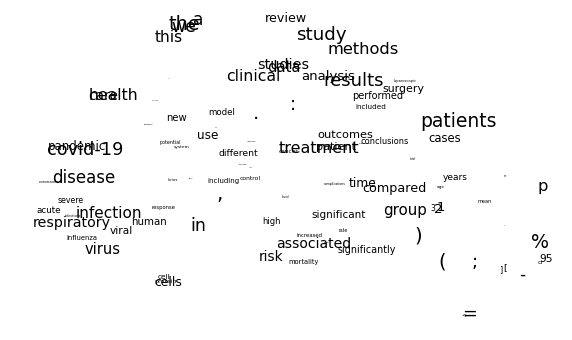

In [230]:
fig = plt.figure(figsize = (10,6))
ax = fig.add_subplot(111)
ax.set_frame_on(False)
plt.scatter(tsneWords[:, 0], tsneWords[:, 1], alpha = 0)#Making the points invisible 
for i, word in enumerate(targetWords):
    ax.annotate(word, (tsneWords[:, 0][i],tsneWords[:, 1][i]), size =  20 * (numWords - i) / numWords)
plt.xticks(())
plt.yticks(())
plt.show()

# Doc2Vec

In [302]:
keywords = ['coronavirus','covid19','covid','virus']

In [313]:
taggedDocs = []
for index, row in df_past_sample.iterrows():
    #Just doing a simple keyword assignment
    docKeywords = [s for s in keywords if s in row['normalized_sents']]
    #docKeywords.append(row['copyrightYear'])
    #docKeywords.append(row['doi']) #This lets us extract individual documnets since doi's are unique
    taggedDocs.append(gensim.models.doc2vec.LabeledSentence(words = row['normalized_sents'], tags = docKeywords))
df_past_sample['TaggedAbstracts'] = taggedDocs

In [317]:
df_past_sample

,sha,source_x,title,doi,pmcid,pubmed_id,license,abstract,publish_time,authors,journal,Microsoft Academic Paper ID,WHO #Covidence,has_full_text,full_text_file,text,tokenized_sent,tokenized_sents2,normalized_sents,TaggedAbstracts
0,NaN,PMC,Human ribosomal protein L13a is dispensable fo...,10.1261/rna.694007,PMC2080596,NaN,unk,"Previously, we demonstrated that treatment of ...",NaN,"Chaudhuri, Sujan; Vyas, Keyur; Kapasi, Purvi; ...",NaN,NaN,NaN,False,NaN,Human ribosomal protein L13a is dispensable fo...,"[[human, ribosomal, protein, l13a, dispensable...","[[Human, ribosomal, protein, L13a, is, dispens...","[[human, ribosomal, protein, l13a, dispensable...","([[human, ribosomal, protein, l13a, dispensabl..."
1,23b23be9334b67bb1a8ebb240c51c112f8c6faec,Elsevier,Purification of recombinant nucleocapsid prote...,10.1016/j.pep.2005.06.015,NaN,16139513.0,els-covid,"Abstract In the present work, a single-step pu...",2006-03-31,"Tan, Yan Peng; Ling, Tau Chuan; Tan, Wen Siang...",Protein Expression and Purification,NaN,NaN,True,custom_license,Purification of recombinant nucleocapsid prote...,"[[purification, recombinant, nucleocapsid, pro...","[[Purification, of, recombinant, nucleocapsid,...","[[purification, recombinant, nucleocapsid, pro...","([[purification, recombinant, nucleocapsid, pr..."
2,363a8d40fdc60c4d83d75c3144df1e49ea8f8102,Elsevier,Chapter 16 Eye and Associated Glands,10.1016/B978-0-12-391448-4.00016-2,NaN,NaN,els-covid,Abstract The eye is susceptible to adverse tox...,2018-12-31,"Dunn, Dale G.; Baker, Julia F.M.; Sorden, Stev...",Boorman's Pathology of the Rat,NaN,NaN,True,custom_license,Chapter 16 Eye and Associated GlandsAbstract T...,"[[chapter, 16, eye, associated, glandsabstract...","[[Chapter, 16, Eye, and, Associated, GlandsAbs...","[[chapter, eye, associate, glandsabstract], [e...","([[chapter, eye, associate, glandsabstract], [..."
3,NaN,Elsevier,New Perspectives in Infectious Diseases,10.1016/j.cveq.2014.10.001,NaN,25441118.0,els-covid,NaN,2014-12-31,"Mealey, Robert H.",Veterinary Clinics of North America: Equine Pr...,NaN,NaN,False,custom_license,nan,[[nan]],[[nan]],[[nan]],"([[nan]], [])"
4,NaN,PMC,The Utility of Preliminary Patient Evaluation ...,10.1093/ofid/ofx163.349,PMC5631788,NaN,cc-by-nc-nd,BACKGROUND: Acute respiratory illnesses are th...,2017 Oct 4,"Sik Kang, Jun; Yoon, Hee; Jhun, Byung Woo; Lim...",Open Forum Infect Dis,NaN,NaN,False,noncomm_use_subset,The Utility of Preliminary Patient Evaluation ...,"[[the, utility, preliminary, patient, evaluati...","[[The, Utility, of, Preliminary, Patient, Eval...","[[utility, preliminary, patient, evaluation, f...","([[utility, preliminary, patient, evaluation, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,f7bbdd316b8d64ca1001b67b96c06efd531893b6,PMC,Tools to Detect Influenza Virus,10.3349/ymj.2013.54.3.560,PMC3635619,23549796.0,cc-by-nc,"In 2009, pandemic influenza A (H1N1) virus (H1...",2013 May 1,"Kim, Dae-Ki; Poudel, Barun",Yonsei Med J,NaN,NaN,True,noncomm_use_subset,"Tools to Detect Influenza VirusIn 2009, pandem...","[[tools, detect, influenza, virusin, 2009, ,, ...","[[Tools, to, Detect, Influenza, VirusIn, 2009,...","[[tool, detect, influenza, virusin, pandemic, ...","([[tool, detect, influenza, virusin, pandemic,..."
4996,1fceaf9f2102c71bf508ebd46c18c9b0cb48e6c3,PMC,"Morbidity, Mortality, and Seasonality of Influ...",10.1371/journal.pone.0161301,PMC5015910,27607330.0,cc0,BACKGROUND: Influenza typically comprises a su...,2016 Sep 8,"Kandeel, Amr; Dawson, Patrick; Labib, Manal; S...",PLoS One,NaN,NaN,True,comm_use_subset,"Morbidity, Mortality, and Seasonality of Influ...","[[morbidity, ,, mortality, ,, seasonality, inf...","[[Morbidity, Mortality, and, Seasonality, of, ...","[[morbidity, mortality, seasonality, influenza...","([[morbidity, mortality, seasonality, influenz..."
4997,64a969ce0d6acc16005bedf8bf21a86b2c7f317f,Elsevier,Collectivités : lieu de rencontre virale,10.1016/j.reval.2014.01.018,NaN,NaN,el

In [316]:
apsD2V = gensim.models.doc2vec.Doc2Vec(df_past_sample['TaggedAbstracts']) #Limiting to 100 dimensions

TypeError: unhashable type: 'list'

# Linguistic Change

In [318]:
import copy

In [319]:
def calc_syn0norm(model):
    """since syn0norm is now depricated"""
    return (model.wv.syn0 / np.sqrt((model.wv.syn0 ** 2).sum(-1))[..., np.newaxis]).astype(np.float32)

def smart_procrustes_align_gensim(base_embed, other_embed, words=None):
    """Procrustes align two gensim word2vec models (to allow for comparison between same word across models).
    Code ported from HistWords <https://github.com/williamleif/histwords> by William Hamilton <wleif@stanford.edu>.
    (With help from William. Thank you!)
    First, intersect the vocabularies (see `intersection_align_gensim` documentation).
    Then do the alignment on the other_embed model.
    Replace the other_embed model's syn0 and syn0norm numpy matrices with the aligned version.
    Return other_embed.
    If `words` is set, intersect the two models' vocabulary with the vocabulary in words (see `intersection_align_gensim` documentation).
    """
    base_embed = copy.copy(base_embed)
    other_embed = copy.copy(other_embed)
    # make sure vocabulary and indices are aligned
    in_base_embed, in_other_embed = intersection_align_gensim(base_embed, other_embed, words=words)

    # get the embedding matrices
    base_vecs = calc_syn0norm(in_base_embed)
    other_vecs = calc_syn0norm(in_other_embed)

    # just a matrix dot product with numpy
    m = other_vecs.T.dot(base_vecs) 
    # SVD method from numpy
    u, _, v = np.linalg.svd(m)
    # another matrix operation
    ortho = u.dot(v) 
    # Replace original array with modified one
    # i.e. multiplying the embedding matrix (syn0norm)by "ortho"
    other_embed.wv.syn0norm = other_embed.wv.syn0 = (calc_syn0norm(other_embed)).dot(ortho)
    return other_embed
    
def intersection_align_gensim(m1,m2, words=None):
    """
    Intersect two gensim word2vec models, m1 and m2.
    Only the shared vocabulary between them is kept.
    If 'words' is set (as list or set), then the vocabulary is intersected with this list as well.
    Indices are re-organized from 0..N in order of descending frequency (=sum of counts from both m1 and m2).
    These indices correspond to the new syn0 and syn0norm objects in both gensim models:
        -- so that Row 0 of m1.syn0 will be for the same word as Row 0 of m2.syn0
        -- you can find the index of any word on the .index2word list: model.index2word.index(word) => 2
    The .vocab dictionary is also updated for each model, preserving the count but updating the index.
    """

    # Get the vocab for each model
    vocab_m1 = set(m1.wv.vocab.keys())
    vocab_m2 = set(m2.wv.vocab.keys())

    # Find the common vocabulary
    common_vocab = vocab_m1&vocab_m2
    if words: common_vocab&=set(words)

    # If no alignment necessary because vocab is identical...
    if not vocab_m1-common_vocab and not vocab_m2-common_vocab:
        return (m1,m2)

    # Otherwise sort by frequency (summed for both)
    common_vocab = list(common_vocab)
    common_vocab.sort(key=lambda w: m1.wv.vocab[w].count + m2.wv.vocab[w].count,reverse=True)

    # Then for each model...
    for m in [m1,m2]:
        # Replace old syn0norm array with new one (with common vocab)
        indices = [m.wv.vocab[w].index for w in common_vocab]
        old_arr = calc_syn0norm(m)
        new_arr = np.array([old_arr[index] for index in indices])
        m.wv.syn0norm = m.wv.syn0 = new_arr

        # Replace old vocab dictionary with new one (with common vocab)
        # and old index2word with new one
        m.index2word = common_vocab
        old_vocab = m.wv.vocab
        new_vocab = {}
        for new_index,word in enumerate(common_vocab):
            old_vocab_obj=old_vocab[word]
            new_vocab[word] = gensim.models.word2vec.Vocab(index=new_index, count=old_vocab_obj.count)
        m.wv.vocab = new_vocab

    return (m1,m2)

In [369]:
def compareModels(df, category, text_column_name='normalized_sents', sort = True, embeddings_raw={}):
    """If you are using time as your category sorting is important"""
    if len(embeddings_raw) == 0:
        embeddings_raw = rawModels(df, category, text_column_name, sort)
    cats = sorted(set(df[category]))
    #These are much quicker
    embeddings_aligned = {}
    for catOuter in cats:
        embeddings_aligned[catOuter] = [embeddings_raw[catOuter]]
        for catInner in cats:
            try:
                embeddings_aligned[catOuter].append(smart_procrustes_align_gensim(embeddings_aligned[catOuter][-1], embeddings_raw[catInner]))
            except Exception:
                pass
    return embeddings_raw, embeddings_aligned

In [366]:
def rawModels(df, category, text_column_name='normalized_sents', sort = True):
    embeddings_raw = {}
    cats = sorted(set(df[category]))
    for cat in cats:
        #This can take a while
        print("Embedding {}".format(cat), end = '\r')
        subsetDF = df[df[category] == cat]
        #You might want to change the W2V parameters
        embeddings_raw[cat] = gensim.models.word2vec.Word2Vec(subsetDF[text_column_name].sum(), min_count=1)
    return embeddings_raw

In [389]:
df_process_new['Year'] = pd.to_numeric(df_process_new['Year'])

In [409]:
df_new_data = df_process_new[df_process_new['Year']>2015].dropna()

In [410]:
df_new_data

,text,abstract,Year,title,tokenized_sents,normalized_sents
0,Modified Isolation Selective Cerebral Perfusio...,Isolation selective cerebral perfusion (ISCP) ...,2019,Modified Isolation Selective Cerebral Perfusio...,"[[Modified, Isolation, Selective, Cerebral, Pe...","[[modify, isolation, selective, cerebral, perf..."
4,Abstracts from the 6th Annual Congress of the ...,Abstracts from the 6th Annual Congress of the ...,2017,Abstracts from the 6th Annual Congress of the ...,"[[Abstracts, from, the, 6th, Annual, Congress,...","[[abstract, annual, congress, association, vas..."
7,Perioperative management for patients with cor...,The coronavirus disease 2019 (COVID-19) is a n...,2020,Perioperative management for patients with cor...,"[[Perioperative, management, for, patients, wi...","[[perioperative, management, patient, coronavi..."
8,Possible Radio Interference Between Video Caps...,Video capsule endoscopy (VCE) is a noninvasive...,2016,Possible Radio Interference Between Video Caps...,"[[Possible, Radio, Interference, Between, Vide...","[[possible, radio, interference, video, capsul..."
9,Lipid moieties of Mycoplasma pneumoniae lipopr...,Vaccine-enhanced disease (VED) occurs as a res...,2020,Lipid moieties of Mycoplasma pneumoniae lipopr...,"[[Lipid, moieties, of, Mycoplasma, pneumoniae,...","[[lipid, moiety, mycoplasma, pneumonia, lipopr..."
...,...,...,...,...,...,...
9992,Labyrinthopeptins exert broad-spectrum antivir...,To counteract the serious health threat posed ...,2019,Labyrinthopeptins exert broad-spectrum antivir...,"[[Labyrinthopeptins, exert, broad, spectrum, a...","[[labyrinthopeptins, exert, broad, spectrum, a..."
9994,BET 1: Prone positioning of awake patients wit...,A short-cut review of the literature was carri...,2020,BET 1: Prone positioning of awake patients wit...,"[[BET, 1], [Prone, positioning, of, awake, pat...","[[bet], [prone, position, awake, patient, acut..."
9996,Tomographic Measurement of Gutters and Analysi...,BACKGROUND The Octopus technique is an off-lab...,2016,Tomographic Measurement of Gutters and Analysi...,"[[Tomographic, Measurement, of, Gutters, and, ...","[[tomographic, measurement, gutter, analysis, ..."
9998,Effect of Jinhua Qinggan granules on novel cor...,OBJECTIVE To evaluate the effectiveness and sa...,2020,Effect of Jinhua Qinggan granules on novel cor...,"[[Effect, of, Jinhua, Qinggan, granules, on, n...","[[effect, jinhua, qinggan, granule, novel, cor..."


In [431]:
df_process_new.Year.describe()

count    7109.000000
mean     2016.560557
std         5.001592
min      1972.000000
25%      2014.000000
50%      2019.000000
75%      2020.000000
max      2021.000000
Name: Year, dtype: float64

<AxesSubplot:>

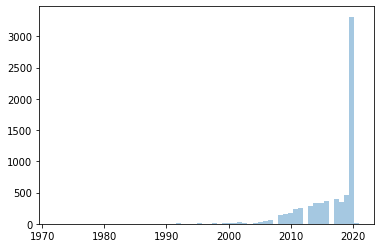

In [437]:
sns.distplot(df_process_new.Year.tolist(), bins=60, kde=False)

<AxesSubplot:>

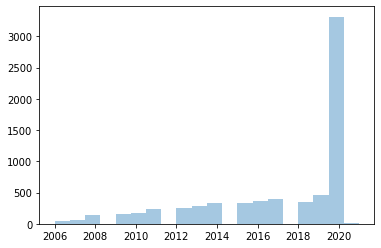

In [443]:
sns.distplot(df_process_new[df_process_new.Year > 2005].Year.tolist(), bins=20, hist=True, kde=False)

In [363]:
df_process_new.dropna()

,text,abstract,Year,title,tokenized_sents,normalized_sents
0,Modified Isolation Selective Cerebral Perfusio...,Isolation selective cerebral perfusion (ISCP) ...,2019,Modified Isolation Selective Cerebral Perfusio...,"[[Modified, Isolation, Selective, Cerebral, Pe...","[[modify, isolation, selective, cerebral, perf..."
3,Changes in glucose-6-phosphate dehydrogenase e...,Hepatocellular carcinoma (HCC) is regarded as ...,2014,Changes in glucose-6-phosphate dehydrogenase e...,"[[Changes, in, glucose-6-phosphate, dehydrogen...","[[change, glucose-6-phosphate, dehydrogenase, ..."
4,Abstracts from the 6th Annual Congress of the ...,Abstracts from the 6th Annual Congress of the ...,2017,Abstracts from the 6th Annual Congress of the ...,"[[Abstracts, from, the, 6th, Annual, Congress,...","[[abstract, annual, congress, association, vas..."
5,High-level Expression of the ORF6 Gene of Porc...,High-level expression of the ORF6 gene of porc...,2003,High-level Expression of the ORF6 Gene of Porc...,"[[High, level, Expression, of, the, ORF6, Gene...","[[high, level, expression, orf6, gene, porcine..."
7,Perioperative management for patients with cor...,The coronavirus disease 2019 (COVID-19) is a n...,2020,Perioperative management for patients with cor...,"[[Perioperative, management, for, patients, wi...","[[perioperative, management, patient, coronavi..."
...,...,...,...,...,...,...
9994,BET 1: Prone positioning of awake patients wit...,A short-cut review of the literature was carri...,2020,BET 1: Prone positioning of awake patients wit...,"[[BET, 1], [Prone, positioning, of, awake, pat...","[[bet], [prone, position, awake, patient, acut..."
9996,Tomographic Measurement of Gutters and Analysi...,BACKGROUND The Octopus technique is an off-lab...,2016,Tomographic Measurement of Gutters and Analysi...,"[[Tomographic, Measurement, of, Gutters, and, ...","[[tomographic, measurement, gutter, analysis, ..."
9997,Birth and pathogenesis of rogue respiratory vi...,Emerging infectious diseases of zoonotic origi...,2015,Birth and pathogenesis of rogue respiratory vi...,"[[Birth, and, pathogenesis, of, rogue, respira...","[[birth, pathogenesis, rogue, respiratory, vir..."
9998,Effect of Jinhua Qinggan granules on novel cor...,OBJECTIVE To evaluate the effectiveness and sa...,2020,Effect of Jinhua Qinggan granules on novel cor...,"[[Effect, of, Jinhua, Qinggan, granules, on, n...","[[effect, jinhua, qinggan, granule, novel, cor..."


In [411]:
rawEmbeddings, comparedEmbeddings = compareModels(df_new_data, 'Year')

In [417]:
rawEmbeddings.keys()

dict_keys([2016, 2017, 2018, 2019, 2020, 2021])

In [379]:
def getDivergenceDF(word, embeddingsDict):
    dists = []
    cats = sorted(set(embeddingsDict.keys()))
    dists = {}
    print(word)
    for cat in cats:
        dists[cat] = []
        for embed in embeddingsDict[cat][1:]:
            dists[cat].append(np.abs(1 - sklearn.metrics.pairwise.cosine_similarity(np.expand_dims(embeddingsDict[cat][0][word], axis = 0),
                                                                             np.expand_dims(embed[word], axis = 0))[0,0]))
    return pandas.DataFrame(dists, index = cats)

coronavirus


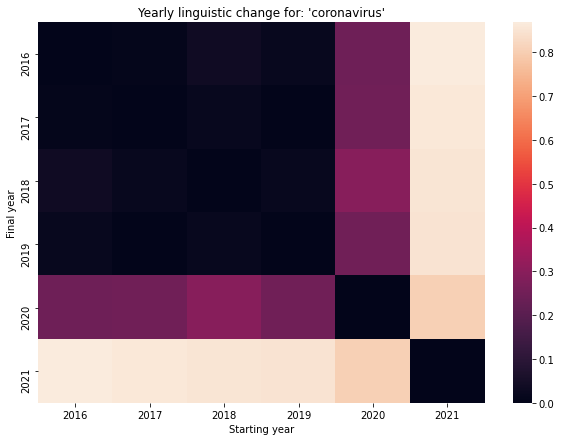

In [418]:
targetWord = 'coronavirus'

pltDF = getDivergenceDF(targetWord, comparedEmbeddings)
fig, ax = plt.subplots(figsize = (10, 7))
seaborn.heatmap(pltDF, ax = ax, annot = False) #set annot True for a lot more information
ax.set_xlabel("Starting year")
ax.set_ylabel("Final year")
ax.set_ylabel("Final year")
ax.set_title("Yearly linguistic change for: '{}'".format(targetWord))
plt.show()

virus


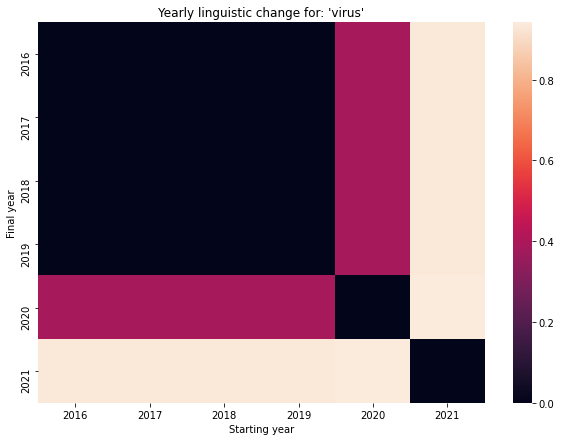

In [419]:
targetWord = 'virus'

pltDF = getDivergenceDF(targetWord, comparedEmbeddings)
fig, ax = plt.subplots(figsize = (10, 7))
seaborn.heatmap(pltDF, ax = ax, annot = False) #set annot True for a lot more information
ax.set_xlabel("Starting year")
ax.set_ylabel("Final year")
ax.set_ylabel("Final year")
ax.set_title("Yearly linguistic change for: '{}'".format(targetWord))
plt.show()

pcr


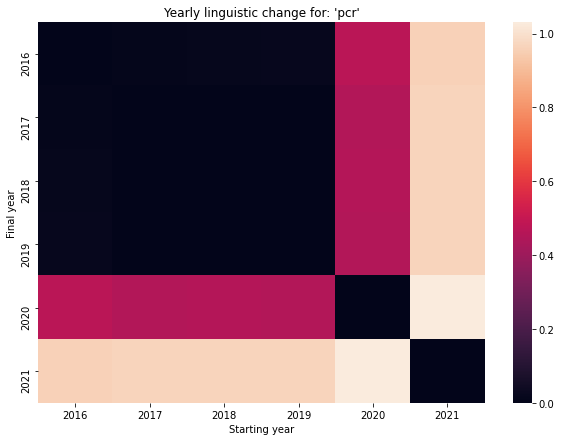

In [423]:
targetWord = 'pcr'

pltDF = getDivergenceDF(targetWord, comparedEmbeddings)
fig, ax = plt.subplots(figsize = (10, 7))
seaborn.heatmap(pltDF, ax = ax, annot = False) #set annot True for a lot more information
ax.set_xlabel("Starting year")
ax.set_ylabel("Final year")
ax.set_ylabel("Final year")
ax.set_title("Yearly linguistic change for: '{}'".format(targetWord))
plt.show()

pathogen


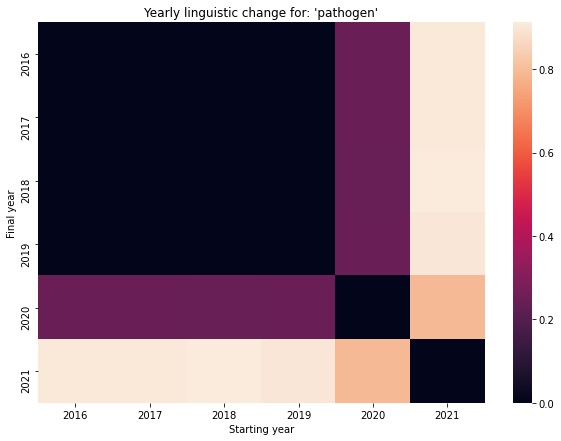

In [427]:
targetWord = 'pathogen'

pltDF = getDivergenceDF(targetWord, comparedEmbeddings)
fig, ax = plt.subplots(figsize = (10, 7))
seaborn.heatmap(pltDF, ax = ax, annot = False) #set annot True for a lot more information
ax.set_xlabel("Starting year")
ax.set_ylabel("Final year")
ax.set_ylabel("Final year")
ax.set_title("Yearly linguistic change for: '{}'".format(targetWord))
plt.show()

hospital


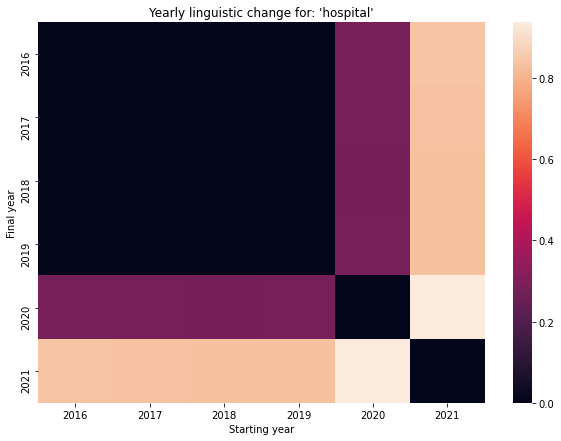

In [430]:
targetWord = 'hospital'

pltDF = getDivergenceDF(targetWord, comparedEmbeddings)
fig, ax = plt.subplots(figsize = (10, 7))
seaborn.heatmap(pltDF, ax = ax, annot = False) #set annot True for a lot more information
ax.set_xlabel("Starting year")
ax.set_ylabel("Final year")
ax.set_ylabel("Final year")
ax.set_title("Yearly linguistic change for: '{}'".format(targetWord))
plt.show()

In [404]:
def findDiverence(word, embeddingsDict):
    cats = sorted(set(embeddingsDict.keys()))
    
    dists = []
    for embed in embeddingsDict[cats[0]][1:]:
        dists.append(1 - sklearn.metrics.pairwise.cosine_similarity(np.expand_dims(embeddingsDict[cats[0]][0][word], axis = 0), np.expand_dims(embed[word], axis = 0))[0,0])
    return sum(dists)

def findMostDivergent(embeddingsDict):
    words = []
    for embeds in embeddingsDict.values():
        for embed in embeds:
            words += list(embed.wv.vocab.keys())
    words = set(words)
    print("Found {} words to compare".format(len(words)))
    return sorted([(w, findDiverence(w, embeddingsDict)) for w in words], key = lambda x: x[1], reverse=True)
    

In [420]:
wordDivergences = findMostDivergent(comparedEmbeddings)

Found 306 words to compare


In [421]:
wordDivergences[:40]

[('intention', 4.013471653684974),
 ('format', 3.800285441800952),
 ('theory', 3.7353816777467728),
 ('preventive', 3.5420097671449184),
 ('academic', 3.2468791007995605),
 ('pass', 3.1643185392022133),
 ('special', 3.0982736498117447),
 ('sectional', 3.0744712110608816),
 ('fund', 2.78494830429554),
 ('nearly', 2.7617336213588715),
 ('analytic', 2.7025365382432938),
 ('crisis', 2.6899873688817024),
 ('regard', 2.643288742750883),
 ('enormous', 2.4864380434155464),
 ('perceive', 2.4791914522647858),
 ('responsiveness', 2.3677447885274887),
 ('attend', 2.3568398356437683),
 ('phenomenon', 2.3228412307798862),
 ('engagement', 2.2798904180526733),
 ('favor', 2.25857610325329),
 ('necessitate', 2.182391695678234),
 ('reproducible', 2.1471133809536695),
 ('personal', 2.1405337676405907),
 ('supplement', 2.08554869890213),
 ('valid', 2.0680268108844757),
 ('resident', 2.0056071877479553),
 ('electronic', 1.989619106054306),
 ('person', 1.9711884260177612),
 ('analyse', 1.9275795966386795),
 

In [422]:
wordDivergences

[('intention', 4.013471653684974),
 ('format', 3.800285441800952),
 ('theory', 3.7353816777467728),
 ('preventive', 3.5420097671449184),
 ('academic', 3.2468791007995605),
 ('pass', 3.1643185392022133),
 ('special', 3.0982736498117447),
 ('sectional', 3.0744712110608816),
 ('fund', 2.78494830429554),
 ('nearly', 2.7617336213588715),
 ('analytic', 2.7025365382432938),
 ('crisis', 2.6899873688817024),
 ('regard', 2.643288742750883),
 ('enormous', 2.4864380434155464),
 ('perceive', 2.4791914522647858),
 ('responsiveness', 2.3677447885274887),
 ('attend', 2.3568398356437683),
 ('phenomenon', 2.3228412307798862),
 ('engagement', 2.2798904180526733),
 ('favor', 2.25857610325329),
 ('necessitate', 2.182391695678234),
 ('reproducible', 2.1471133809536695),
 ('personal', 2.1405337676405907),
 ('supplement', 2.08554869890213),
 ('valid', 2.0680268108844757),
 ('resident', 2.0056071877479553),
 ('electronic', 1.989619106054306),
 ('person', 1.9711884260177612),
 ('analyse', 1.9275795966386795),
 

# Targetted Word Embedding for Jan

In [548]:
tnytTargetWords = ['virus','coronavirus','covid','pcr','cell','protein']

In [549]:
tnytTargetWords += ['covs','nl63','hcov','oc43','mink','bat','ferret','h1n1','hcov-229e','sars','disease','corona','wuhan','outbreak','worldwide','common','government','china','hospital','pneumonia','community','epidemic','influenza']

In [574]:
tnytTargetWords

['virus',
 'coronavirus',
 'covid',
 'pcr',
 'cell',
 'protein',
 'covs',
 'nl63',
 'hcov',
 'oc43',
 'mink',
 'bat',
 'ferret',
 'h1n1',
 'hcov-229e',
 'sars',
 'disease',
 'corona',
 'wuhan',
 'outbreak',
 'worldwide',
 'common',
 'government',
 'china',
 'hospital',
 'pneumonia',
 'community',
 'epidemic',
 'influenza']

In [456]:
df_process_new.head()

,text,abstract,Year,title,tokenized_sents,normalized_sents
0,Modified Isolation Selective Cerebral Perfusio...,Isolation selective cerebral perfusion (ISCP) ...,2019,Modified Isolation Selective Cerebral Perfusio...,"[[Modified, Isolation, Selective, Cerebral, Pe...","[[modify, isolation, selective, cerebral, perf..."
3,Changes in glucose-6-phosphate dehydrogenase e...,Hepatocellular carcinoma (HCC) is regarded as ...,2014,Changes in glucose-6-phosphate dehydrogenase e...,"[[Changes, in, glucose-6-phosphate, dehydrogen...","[[change, glucose-6-phosphate, dehydrogenase, ..."
4,Abstracts from the 6th Annual Congress of the ...,Abstracts from the 6th Annual Congress of the ...,2017,Abstracts from the 6th Annual Congress of the ...,"[[Abstracts, from, the, 6th, Annual, Congress,...","[[abstract, annual, congress, association, vas..."
5,High-level Expression of the ORF6 Gene of Porc...,High-level expression of the ORF6 gene of porc...,2003,High-level Expression of the ORF6 Gene of Porc...,"[[High, level, Expression, of, the, ORF6, Gene...","[[high, level, expression, orf6, gene, porcine..."
7,Perioperative management for patients with cor...,The coronavirus disease 2019 (COVID-19) is a n...,2020,Perioperative management for patients with cor...,"[[Perioperative, management, for, patients, wi...","[[perioperative, management, patient, coronavi..."


In [515]:
senReleasesW2V_jan = gensim.models.word2vec.Word2Vec(df_process_new['normalized_sents'].sum())

In [551]:
wordsSubMatrix = []
for word in tnytTargetWords:
    wordsSubMatrix.append(senReleasesW2V_jan[word])
wordsSubMatrix = np.array(wordsSubMatrix)

In [552]:
pcaWordsNYT = sklearn.decomposition.PCA(n_components = 5).fit(wordsSubMatrix)
reducedPCA_dataNYT = pcaWordsNYT.transform(wordsSubMatrix)
#T-SNE is theoretically better, but you should experiment
tsneWordsNYT = sklearn.manifold.TSNE(n_components = 2).fit_transform(reducedPCA_dataNYT)

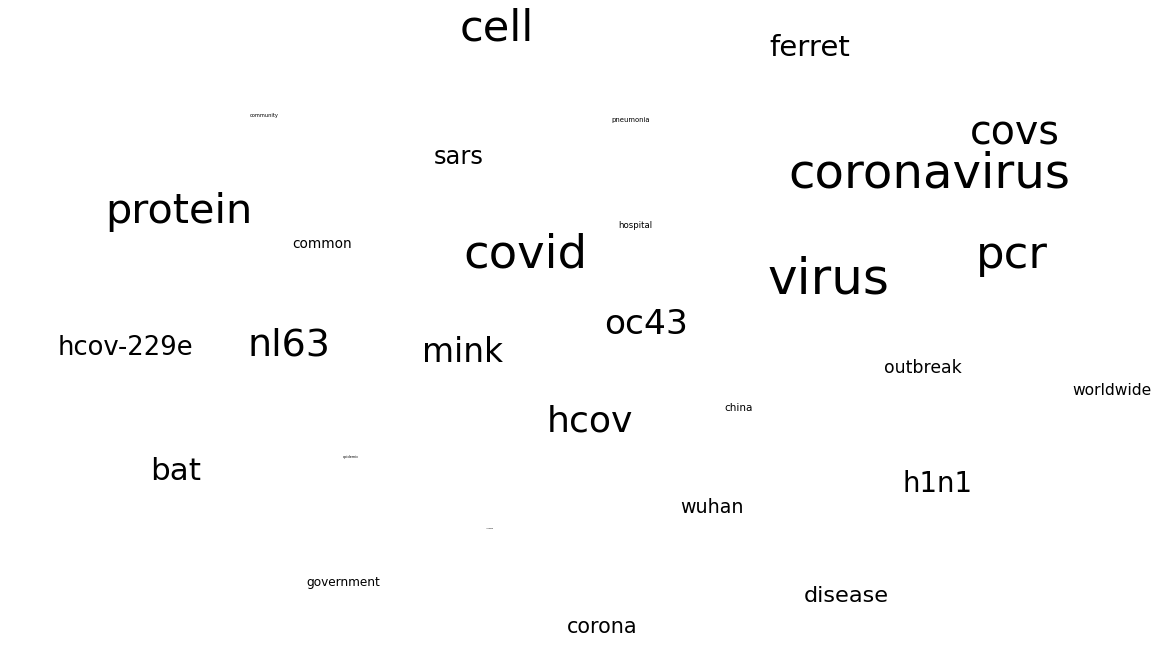

In [553]:
fig = plt.figure(figsize = (20,12))
ax = fig.add_subplot(111)
ax.set_frame_on(False)
plt.scatter(tsneWordsNYT[:, 0], tsneWordsNYT[:, 1], alpha = 0) #Making the points invisible
for i, word in enumerate(tnytTargetWords):
    ax.annotate(word, (tsneWordsNYT[:, 0][i],tsneWordsNYT[:, 1][i]), size =  50 * (len(tnytTargetWords) - i) / len(tnytTargetWords))
plt.xticks(())
plt.yticks(())
plt.show()

# Targetted Word Embedding for March

In [492]:
senReleasesW2V_mar = gensim.models.word2vec.Word2Vec(df_process['tokenized_sent'].sum())

In [575]:
tnytTargetWords = ['virus','coronavirus','pcr','cell','protein']

In [576]:
tnytTargetWords += ['covs','nl63','hcov','oc43','mink','bat','ferret','h1n1','hcov-229e','sars','disease','corona','wuhan','sars','china','outbreak','worldwide','common','deltacoronavirus','government','hospital','pseudovirus']

In [577]:
len(tnytTargetWords)

27

In [538]:
wordsSubMatrix = []
for word in tnytTargetWords:
    wordsSubMatrix.append(senReleasesW2V_mar[word])
wordsSubMatrix = np.array(wordsSubMatrix)
#wordsSubMatrix

In [539]:
pcaWordsNYT = sklearn.decomposition.PCA(n_components = 3).fit(wordsSubMatrix)
reducedPCA_dataNYT = pcaWordsNYT.transform(wordsSubMatrix)
#T-SNE is theoretically better, but you should experiment
tsneWordsNYT = sklearn.manifold.TSNE(n_components = 2).fit_transform(reducedPCA_dataNYT)

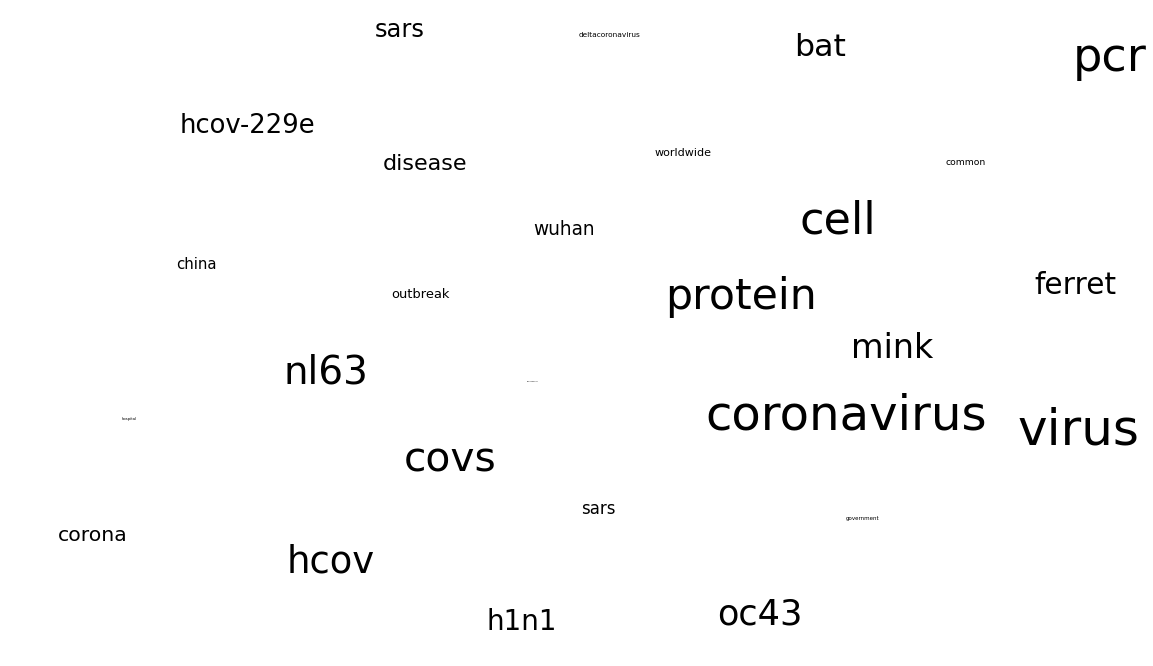

In [540]:
fig = plt.figure(figsize = (20,12))
ax = fig.add_subplot(111)
ax.set_frame_on(False)
plt.scatter(tsneWordsNYT[:, 0], tsneWordsNYT[:, 1], alpha = 0) #Making the points invisible
for i, word in enumerate(tnytTargetWords):
    ax.annotate(word, (tsneWordsNYT[:, 0][i],tsneWordsNYT[:, 1][i]), size =  50 * (len(tnytTargetWords) - i) / len(tnytTargetWords))
plt.xticks(())
plt.yticks(())
plt.show()

# Two year's window

In [561]:
df_new_data2 = df_process_new[df_process_new['Year']>2018].dropna()

In [564]:
rawEmbeddings2, comparedEmbeddings2 = compareModels(df_new_data2, 'Year')

In [565]:
wordDivergences = findMostDivergent(comparedEmbeddings2)

Found 339 words to compare


In [566]:
wordDivergences[:40]

[('intention', 1.4889035150408745),
 ('outcome', 1.431127592921257),
 ('acute', 1.4276201128959656),
 ('pcr', 1.4207275956869125),
 ('regression', 1.3976183533668518),
 ('show', 1.3922188580036163),
 ('workload', 1.3609882965683937),
 ('spread', 1.3494904711842537),
 ('virus', 1.3440573923289776),
 ('low', 1.3406400070525706),
 ('result', 1.3319563269615173),
 ('detection', 1.3316223919391632),
 ('emergency', 1.3301253914833069),
 ('mediate', 1.3234166353940964),
 ('flow', 1.29937082529068),
 ('database', 1.2921327278017998),
 ('case', 1.2904850170016289),
 ('age', 1.2865095287561417),
 ('type', 1.2847683504223824),
 ('month', 1.2814495861530304),
 ('vs.', 1.2794695422053337),
 ('control', 1.279050838202238),
 ('learn', 1.2778406254947186),
 ('receive', 1.2775883451104164),
 ('h', 1.2763148676604033),
 ('positive', 1.2755695804953575),
 ('disease', 1.2736836709082127),
 ('sars', 1.2735513895750046),
 ('reduce', 1.266117749735713),
 ('reliable', 1.265695258975029),
 ('novel', 1.26188398

In [569]:
wordDivergences[-50:]

[('l.', 0.8907654583454132),
 ('determine', 0.8904576003551483),
 ('resident', 0.8895042687654495),
 ('sensitive', 0.8894046396017075),
 ('reveal', 0.8890310823917389),
 ('fund', 0.8876776695251465),
 ('ophthalmic', 0.8850070685148239),
 ('generate', 0.8843332529067993),
 ('skin', 0.8806729912757874),
 ('platform', 0.8782591223716736),
 ('academic', 0.8770151436328888),
 ('subsequent', 0.8753038346767426),
 ('frailty', 0.8748839497566223),
 ('deliver', 0.8747560232877731),
 ('serotype', 0.874008521437645),
 ('perceive', 0.8722667843103409),
 ('perception', 0.8696219325065613),
 ('particular', 0.8673700839281082),
 ('capacity', 0.8672958463430405),
 ('feedback', 0.8672573417425156),
 ('well', 0.8655518144369125),
 ('need', 0.8648011386394501),
 ('west', 0.8628285676240921),
 ('behavioral', 0.8608847856521606),
 ('effort', 0.8512511998414993),
 ('necessary', 0.8505537062883377),
 ('variation', 0.8493224531412125),
 ('mediator', 0.8492013961076736),
 ('format', 0.8465223163366318),
 ('pay

In [570]:
wordDivergences

[('intention', 1.4889035150408745),
 ('outcome', 1.431127592921257),
 ('acute', 1.4276201128959656),
 ('pcr', 1.4207275956869125),
 ('regression', 1.3976183533668518),
 ('show', 1.3922188580036163),
 ('workload', 1.3609882965683937),
 ('spread', 1.3494904711842537),
 ('virus', 1.3440573923289776),
 ('low', 1.3406400070525706),
 ('result', 1.3319563269615173),
 ('detection', 1.3316223919391632),
 ('emergency', 1.3301253914833069),
 ('mediate', 1.3234166353940964),
 ('flow', 1.29937082529068),
 ('database', 1.2921327278017998),
 ('case', 1.2904850170016289),
 ('age', 1.2865095287561417),
 ('type', 1.2847683504223824),
 ('month', 1.2814495861530304),
 ('vs.', 1.2794695422053337),
 ('control', 1.279050838202238),
 ('learn', 1.2778406254947186),
 ('receive', 1.2775883451104164),
 ('h', 1.2763148676604033),
 ('positive', 1.2755695804953575),
 ('disease', 1.2736836709082127),
 ('sars', 1.2735513895750046),
 ('reduce', 1.266117749735713),
 ('reliable', 1.265695258975029),
 ('novel', 1.26188398